<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;">Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;">Part (3): 3-Stage Causal Cascade — Stocks → Oil → Gold</h3>


In this section the usage of all models in Part (2) will be used. In order to get to a model that is closer to the reality situation, we choose the gold as the output for this process.

In this process will avoid any leakage from the standard features related to stock markets, oil and gold.

We'll start with predicting the stock market prices then the output of this stage will be the input for the oil prediction prices which will all be combined as an input for prediction of gold prices.

The gold prediction will follow our method of full features model and top features selections and these two models will be saved.

<h4 style="color: #CEDDF4;">1. Import Libraries</h4>

In [2]:
import os, math, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error
warnings.filterwarnings('ignore')

<h4 style="color: #CEDDF4;">2. Paths</h4>

In [3]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

TEST_START  = '2025-12-31'   # train cutoff (exclusive)
TEST_END    = '2026-04-30'   # prediction horizon (inclusive)

<h4 style="color: #CEDDF4;">3. Market Registry (EGX30 Excluded)</h4>

In [4]:
STOCK_MARKETS = [
    ('NASDAQ',     'nasdaq_price_usd',            'USD', '#0057B8', '#CCE0F5'),
    ('S&P 500',    'sp500_price_usd',             'USD', '#006644', '#CCF0E0'),
    ('Dow Jones',  'dowjones_price_usd',          'USD', '#7B2D8B', '#EFD9F7'),
    ('Shanghai',   'china_shanghai_price_usd',    'USD', '#C0392B', '#F9D6D3'),
    ('Hong Kong',  'hongkong_hongkong_price_usd', 'USD', '#E67E22', '#FDEBD0'),
    ('London',     'uk_london_price_usd',         'USD', '#2C3E50', '#D5D8DC'),
    ('Tokyo',      'japan_tokyo_price_usd',       'USD', '#8B1A1A', '#FADBD8'),
    ('EGX30',      'egx30_price_egp',             'EGP', '#006B3C', '#D5F5E3'),
]

# USD-only markets — used as inputs to Stage 2 & 3 (EGX30 excluded: EGP-denominated)
USD_STOCK_MARKETS = [m for m in STOCK_MARKETS if m[2] == 'USD']

# ALL stock columns in the master table (used to strip cross-market leakage)
ALL_STOCK_COLS = [
    'china_shanghai_price_usd','china_shanghai_high_usd','china_shanghai_low_usd','china_shanghai_open_usd',
    'egx30_price_egp','egx30_high_price_egp','egx30_low_price_egp','egx30_change_percent',
    'hongkong_hongkong_price_usd','hongkong_hongkong_high_usd','hongkong_hongkong_low_usd','hongkong_hongkong_open_usd',
    'japan_tokyo_price_usd','japan_tokyo_high_usd','japan_tokyo_low_usd','japan_tokyo_open_usd',
    'uk_london_price_usd','uk_london_high_usd','uk_london_low_usd','uk_london_open_usd',
    'dowjones_price_usd','dowjones_high_usd','dowjones_low_usd','dowjones_open_usd',
    'nasdaq_price_usd','nasdaq_high_usd','nasdaq_low_usd','nasdaq_open_usd',
    'sp500_price_usd','sp500_high_usd','sp500_low_usd','sp500_open_usd',
]

# Shared leakage keywords applied in every stage
BASE_LEAKAGE_KW = [
    '_open_','_high_','_low_','_open','_high','_low',
    'gpr_event','ai_gpr_Unnamed',
    'gold_price_oz_egp',
    'cbe_inflations_headline_inflation_yy',
    'cbe_inflations_core_inflation_yy',
    '_energy_','egpusd_value',
    'dollar_historical_data_value',
    'cpi_PCPIPCH',
]

# Complete commodity leakage list — used in Stage 1 to remove all oil/gold signals
COMMODITY_COLS_KW = [
    'gold_price', 'gold_vi',                          # gold price + volatility index
    'silver_price',                                    # silver (correlated commodity)
    'brent_oil_price', 'wti_price', 'opec_basket',    # oil benchmarks
    'oil_vi', 'oil_price',                             # oil volatility + generic
    'copper_price',                                    # copper (industrial commodity)
]

# Will be populated by Stage 1 — keyed by market name
stock_pred_series = {}   # {name: pd.Series(index=dates, values=predicted_prices)}
stock_results     = {}   # metrics + metadata

<h4 style="color: #CEDDF4;">4. Shared Visualization Helper</h4>

In [5]:
def plot_prediction(name, target_col, currency, accent, fill,
                    test_df, save_path=None, top_k=15,
                    subtitle_extra=''):
    """
    Replicates the exact chart style of the original notebook.
    test_df must contain columns: date, <target_col>, pred_price, pred_price_top, target
    """
    def kpis(a, p):
        mae  = np.mean(np.abs(a - p))
        rmse = np.sqrt(np.mean((a - p)**2))
        r2   = 1 - np.sum((a - p)**2) / np.sum((a - a.mean())**2)
        mape = np.mean(np.abs((a - p) / np.where(a == 0, 1e-9, a))) * 100
        return mae, rmse, r2, mape

    plot_df   = test_df.sort_values('date').copy()
    dates     = plot_df['date'].values
    actual    = plot_df[target_col].values
    full_pred = plot_df['pred_price'].values
    top_pred  = plot_df['pred_price_top'].values

    mae_f, rmse_f, r2_f, mape_f = kpis(actual, full_pred)
    mae_t, rmse_t, r2_t, mape_t = kpis(actual, top_pred)

    PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
    MKT_DARK, MKT_FILL = accent, fill
    NAVY, CRIMSON = '#1B3A6B', '#C0392B'
    TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
    GREEN_KPI, GREEN_BG = '#0B6E4F', '#E8F5F0'
    RED_KPI = '#8B1A1A'
    AMBER_KPI, AMBER_BG = '#7A4F00', '#FEF3CD'

    fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
    outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                              hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

    ax_head = fig.add_subplot(outer[0])
    ax_head.set_facecolor(WHITE); ax_head.set_xlim(0,1); ax_head.set_ylim(0,1)
    for sp in ax_head.spines.values(): sp.set_visible(False)
    ax_head.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)
    ax_head.add_patch(mpatches.FancyBboxPatch((0,0.1),0.004,0.8,
        boxstyle='square,pad=0',fc=MKT_FILL,ec='none',
        transform=ax_head.transAxes,clip_on=False))
    ax_head.text(0.012,0.72,f'{name.upper()} PRICE FORECASTING',
        transform=ax_head.transAxes,fontsize=20,fontweight='bold',color=TEXT_H,va='center')
    ax_head.text(0.012, 0.52, 'Cascade Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
    sub = (f'Actual prices vs ML predictions · Jan–Apr 2026 · {currency}'
           + (f'  ·  {subtitle_extra}' if subtitle_extra else ''))
    ax_head.text(0.012,0.28,sub,
        transform=ax_head.transAxes,fontsize=11,color=TEXT_M,va='center')
    ax_head.text(0.99,0.72,'Full Feature Model',
        transform=ax_head.transAxes,fontsize=10,fontweight='bold',color=NAVY,ha='right',va='center')
    ax_head.text(0.99,0.28,f'Top-{top_k} Feature Model',
        transform=ax_head.transAxes,fontsize=10,fontweight='bold',color=CRIMSON,ha='right',va='center')
    ax_head.axhline(0,color=BORDER,linewidth=1.2)

    inner = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=outer[1],
                                             height_ratios=[5,1],hspace=0.06)
    ax   = fig.add_subplot(inner[0])
    ax_r = fig.add_subplot(inner[1],sharex=ax)

    for a in [ax,ax_r]:
        a.set_facecolor(WHITE); a.tick_params(colors=TEXT_M,labelsize=10)
        for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
        a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

    ax.fill_between(dates,actual,actual.min()-actual.min()*0.01,
        color=MKT_FILL,alpha=0.12,zorder=1)
    ax.fill_between(dates,actual,full_pred,
        where=(actual>=full_pred),color=NAVY,alpha=0.06,zorder=2,interpolate=True)
    ax.fill_between(dates,actual,full_pred,
        where=(actual<full_pred),color=CRIMSON,alpha=0.06,zorder=2,interpolate=True)
    ax.plot(dates,actual,   color=MKT_DARK,linewidth=2.8,zorder=6,
            solid_capstyle='round',label='Actual Price')
    ax.plot(dates,full_pred,color=NAVY,linewidth=2.0,linestyle=(0,(7,2)),
            zorder=5,alpha=0.95,label='Full Feature Model')
    ax.plot(dates,top_pred, color=CRIMSON,linewidth=1.8,linestyle=(0,(3,2)),
            zorder=4,alpha=0.90,label=f'Top-{top_k} Feature Model')

    for ms in pd.date_range(plot_df['date'].min(),plot_df['date'].max(),freq='MS'):
        ax.axvline(ms,color=BORDER,linewidth=1.0,linestyle='--',alpha=0.9,zorder=1)
    ax.set_xlim(dates[0],dates[-1])

    pidx=np.argmax(actual); pval=actual[pidx]; pdate=dates[pidx]
    tidx=np.argmin(actual); tval=actual[tidx]; tdate=dates[tidx]
    offset=actual.mean()*0.03
    for x,y,lbl,col,ya,arc in [
        (pdate,pval,f'Peak\n{currency} {pval:,.0f}',  GREEN_KPI,pval+offset, 0.3),
        (tdate,tval,f'Trough\n{currency} {tval:,.0f}',RED_KPI,  tval-offset,-0.3),
    ]:
        ax.annotate(lbl,xy=(x,y),xytext=(x,ya),color=col,
            fontsize=8.5,fontweight='bold',ha='center',
            arrowprops=dict(arrowstyle='->',color=col,
                connectionstyle=f'arc3,rad={arc}',lw=1.3),
            bbox=dict(boxstyle='round,pad=0.3',fc=WHITE,ec=BORDER,alpha=0.9,lw=0.8),
            zorder=10)
        ax.scatter([x],[y],color=col,s=50,zorder=11,edgecolors=WHITE,linewidths=1.5)

    ax.yaxis.grid(True,color=GRID,linewidth=0.8,zorder=0); ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:,.0f}'))
    ax.set_ylabel(f'{name} Price ({currency})',color=TEXT_B,fontsize=11,
                  fontweight='bold',labelpad=10)
    ax.tick_params(axis='x',labelbottom=False)
    ax.legend(handles=[
        Line2D([0],[0],color=MKT_DARK,linewidth=2.8,label='Actual Price'),
        Line2D([0],[0],color=NAVY,linewidth=2.0,linestyle=(0,(7,2)),label='Full Feature Model'),
        Line2D([0],[0],color=CRIMSON,linewidth=1.8,linestyle=(0,(3,2)),label=f'Top-{top_k} Feature Model'),
    ],loc='upper left',frameon=True,framealpha=0.95,facecolor=WHITE,edgecolor=BORDER,
       labelcolor=TEXT_B,fontsize=10,borderpad=0.9,handlelength=2.8,
       title='Series',title_fontsize=9)

    res = actual - full_pred
    ax_r.bar(dates,res,color=[GREEN_KPI if v>=0 else CRIMSON for v in res],
             alpha=0.65,width=0.85,zorder=3)
    ax_r.axhline(0,color=TEXT_M,linewidth=0.8,zorder=4)
    ax_r.yaxis.grid(True,color=GRID,linewidth=0.5,zorder=0); ax_r.set_axisbelow(True)
    ax_r.set_ylabel('Residual\n(Full Model)',color=TEXT_M,fontsize=8.5,labelpad=6)
    ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:+,.0f}'))
    ax_r.tick_params(colors=TEXT_M,labelsize=9)
    pad=max(abs(res.min()),abs(res.max()))*1.5 if res.max()!=res.min() else 1
    ax_r.set_ylim(-pad,pad)
    ax_r.xaxis.set_major_locator(mdates.MonthLocator())
    ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_r.tick_params(axis='x',labelsize=10,colors=TEXT_B)

    ax_kpi = fig.add_subplot(outer[2])
    ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
    for sp in ax_kpi.spines.values(): sp.set_visible(False)
    ax_kpi.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)
    ax_kpi.axhline(1.0,color=BORDER,linewidth=1.0)

    kpi_cards = [
        ('MAE', f'{mae_f:,.1f}', f'{mae_t:,.1f}', AMBER_KPI, AMBER_BG),
        ('RMSE',f'{rmse_f:,.1f}',f'{rmse_t:,.1f}',AMBER_KPI, AMBER_BG),
        ('R²',  f'{r2_f:.3f}',   f'{r2_t:.3f}',   GREEN_KPI, GREEN_BG),
        ('MAPE',f'{mape_f:.2f}%',f'{mape_t:.2f}%', AMBER_KPI, AMBER_BG),
    ]
    card_w=0.19; gap=(1.0-len(kpi_cards)*card_w)/(len(kpi_cards)+1)
    for i,(metric,vf,vt,tcol,bgcol) in enumerate(kpi_cards):
        x0=gap+i*(card_w+gap); xc=x0+card_w/2
        ax_kpi.add_patch(mpatches.FancyBboxPatch((x0,0.06),card_w,0.82,
            boxstyle='round,pad=0.02',fc=bgcol,ec=BORDER,linewidth=0.8,
            transform=ax_kpi.transAxes,clip_on=False))
        ax_kpi.text(xc,0.82,metric,transform=ax_kpi.transAxes,
            ha='center',va='center',fontsize=10,fontweight='bold',color=TEXT_M)
        ax_kpi.add_patch(mpatches.FancyBboxPatch((x0+0.005,0.60),card_w-0.01,0.005,
            boxstyle='square,pad=0',fc=BORDER,ec='none',
            transform=ax_kpi.transAxes,clip_on=False))
        ax_kpi.text(xc,0.48,vf,transform=ax_kpi.transAxes,
            ha='center',va='center',fontsize=12,fontweight='bold',color=NAVY)
        ax_kpi.text(xc,0.30,'Full Model',transform=ax_kpi.transAxes,
            ha='center',va='center',fontsize=7.5,color=TEXT_M)
        ax_kpi.text(xc,0.14,f'Top-{top_k}: {vt}',transform=ax_kpi.transAxes,
            ha='center',va='center',fontsize=8.5,fontweight='bold',color=CRIMSON)

    if save_path:
        plt.savefig(save_path,dpi=300,bbox_inches='tight',facecolor=PAGE)
    plt.show()
    return mae_f, rmse_f, r2_f, mape_f, mae_t, rmse_t, r2_t, mape_t

<h4 style="color: #CEDDF4;">5. STAGE 1 — Stock Market Prediction</h4>
<p style="color:#AABBCC;">Gold and oil columns are <b>completely removed</b> from features. EGX30 is excluded. Each market is trained and evaluated independently. Predicted price series are stored for Stage 2 & 3.</p>

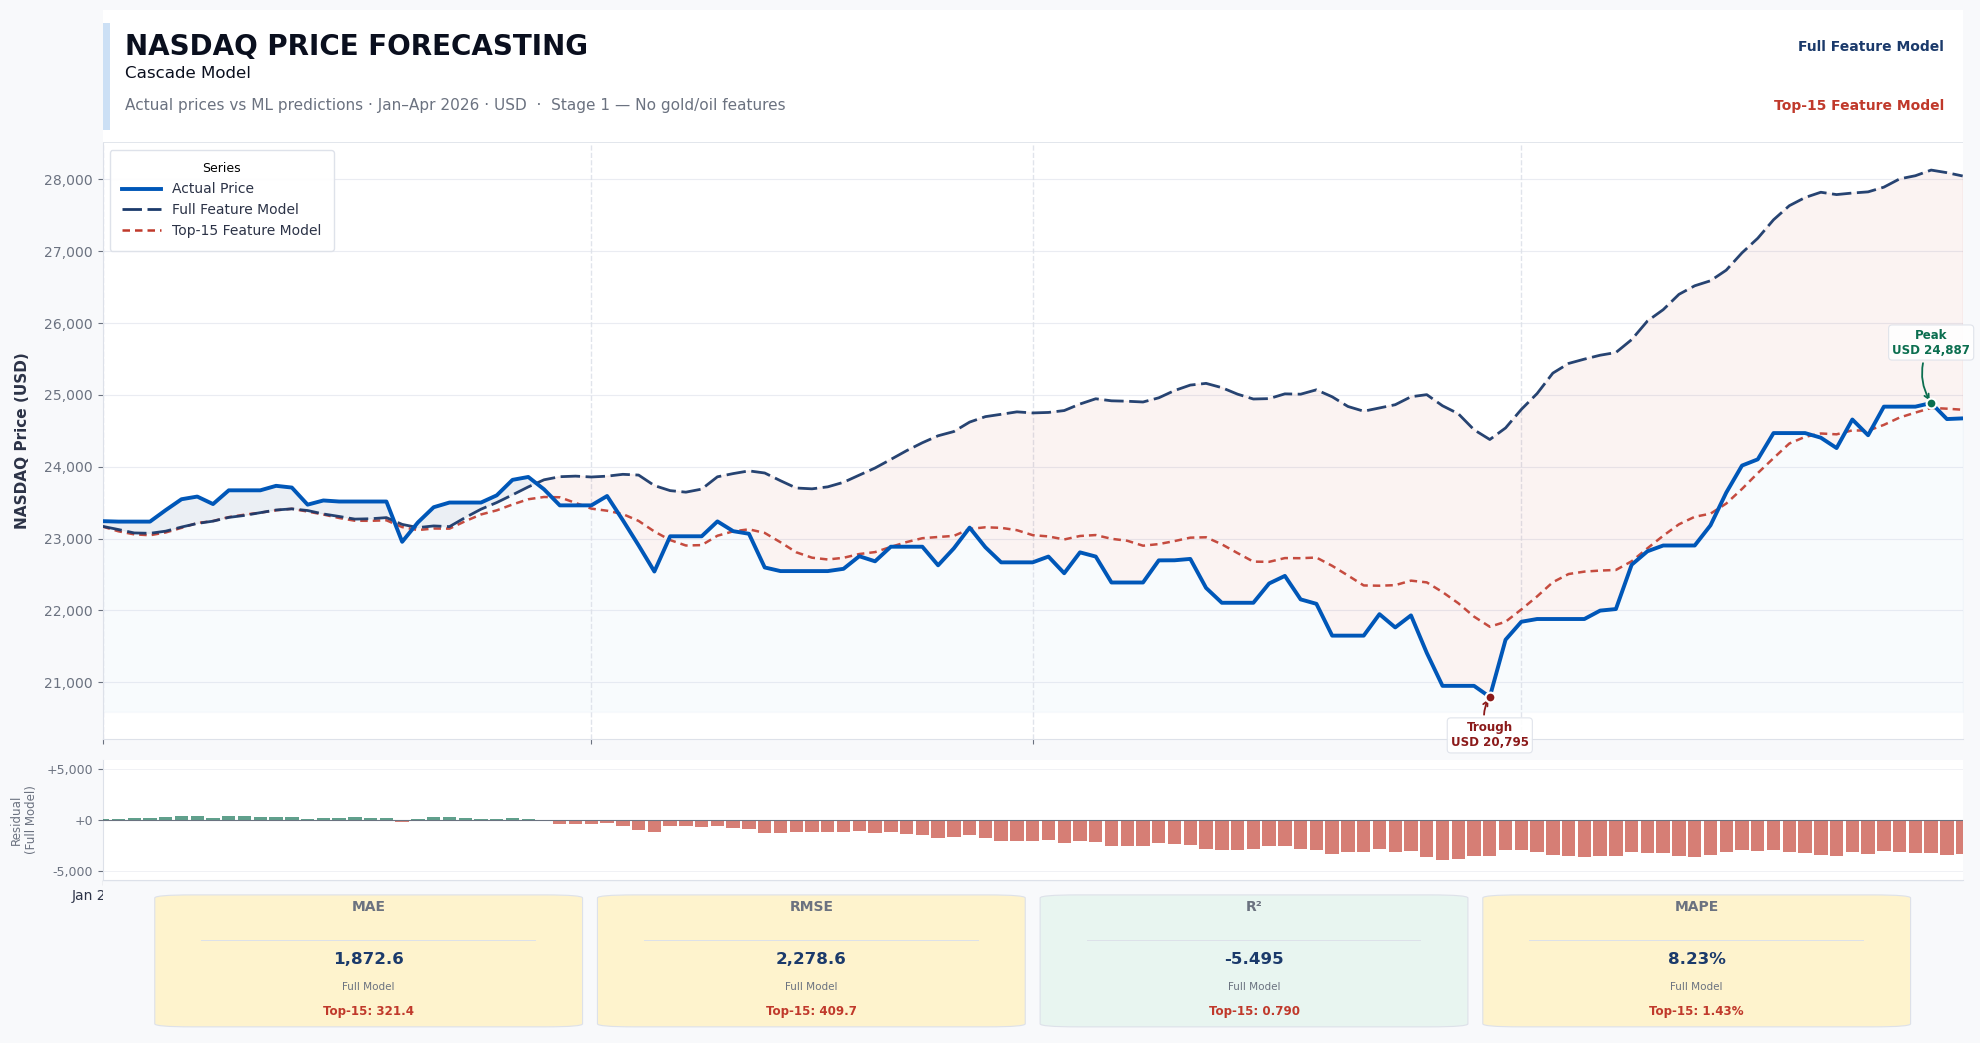

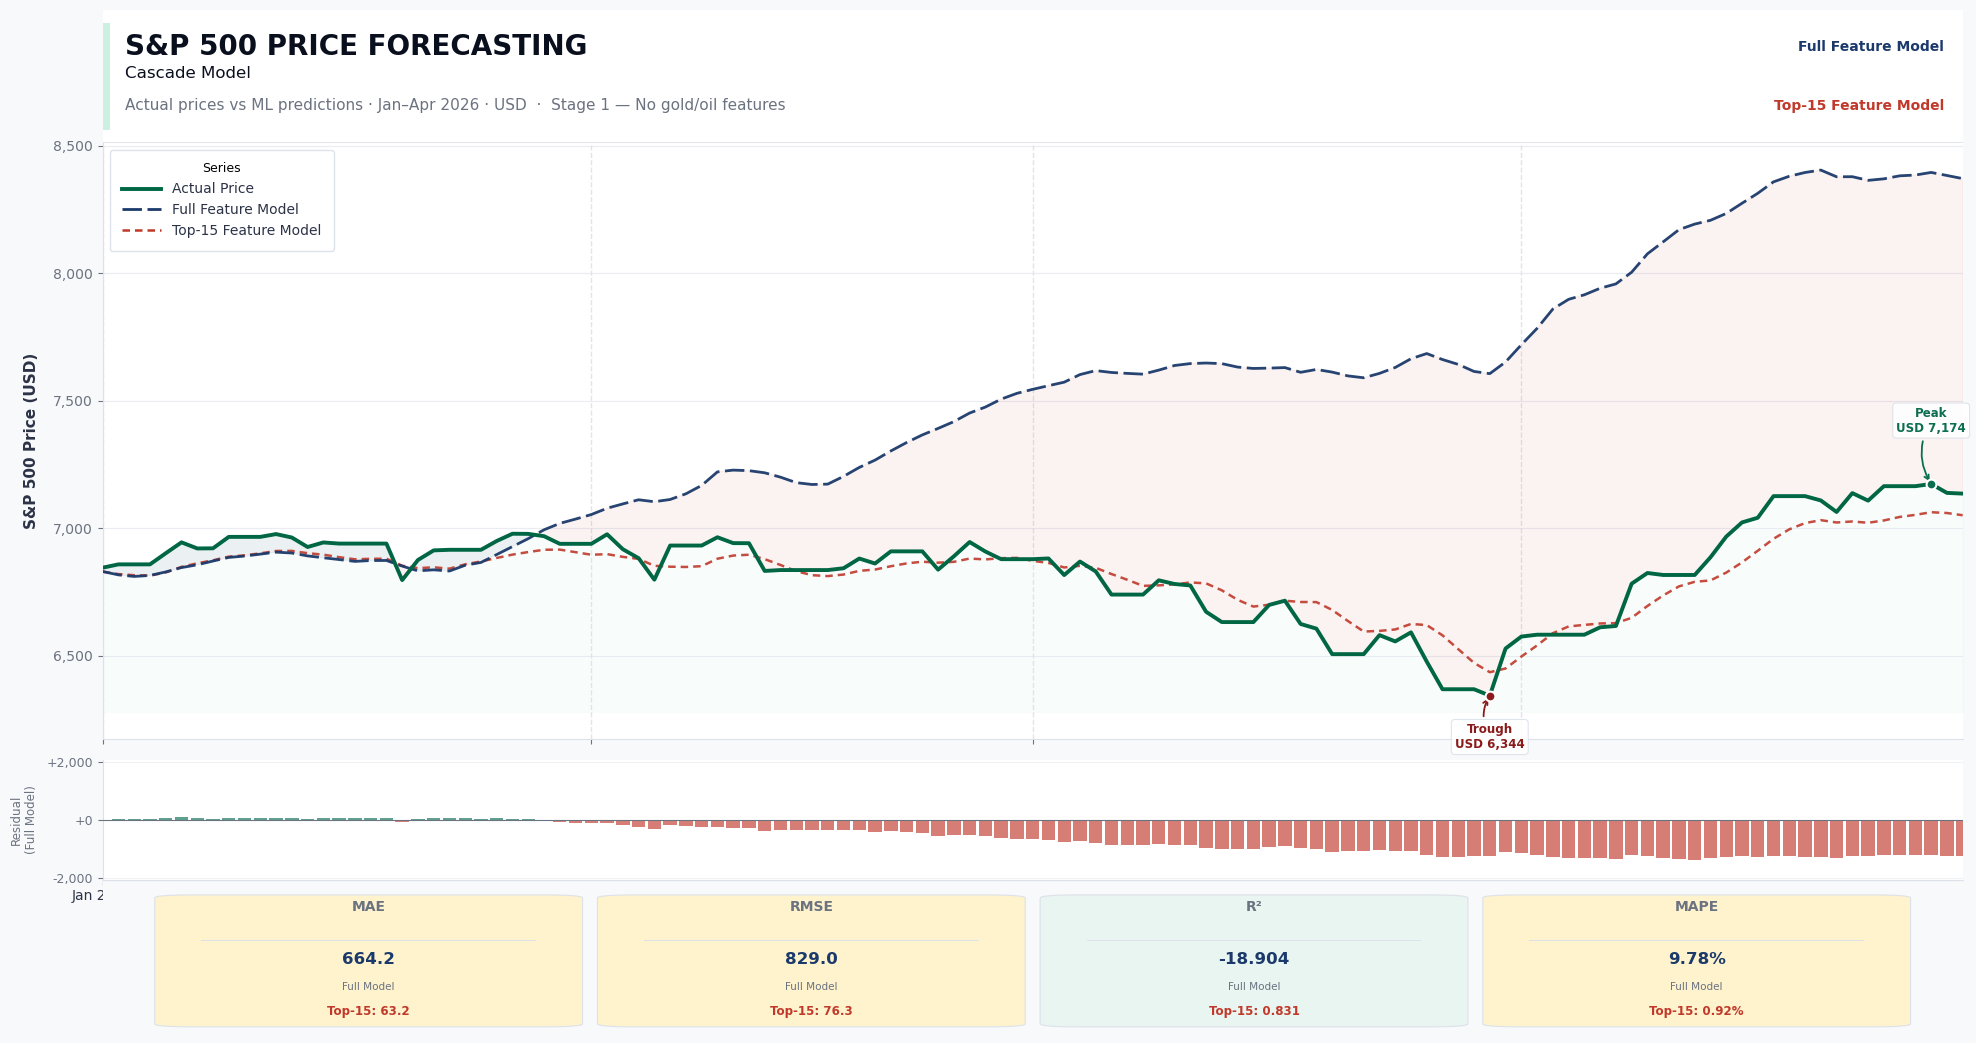

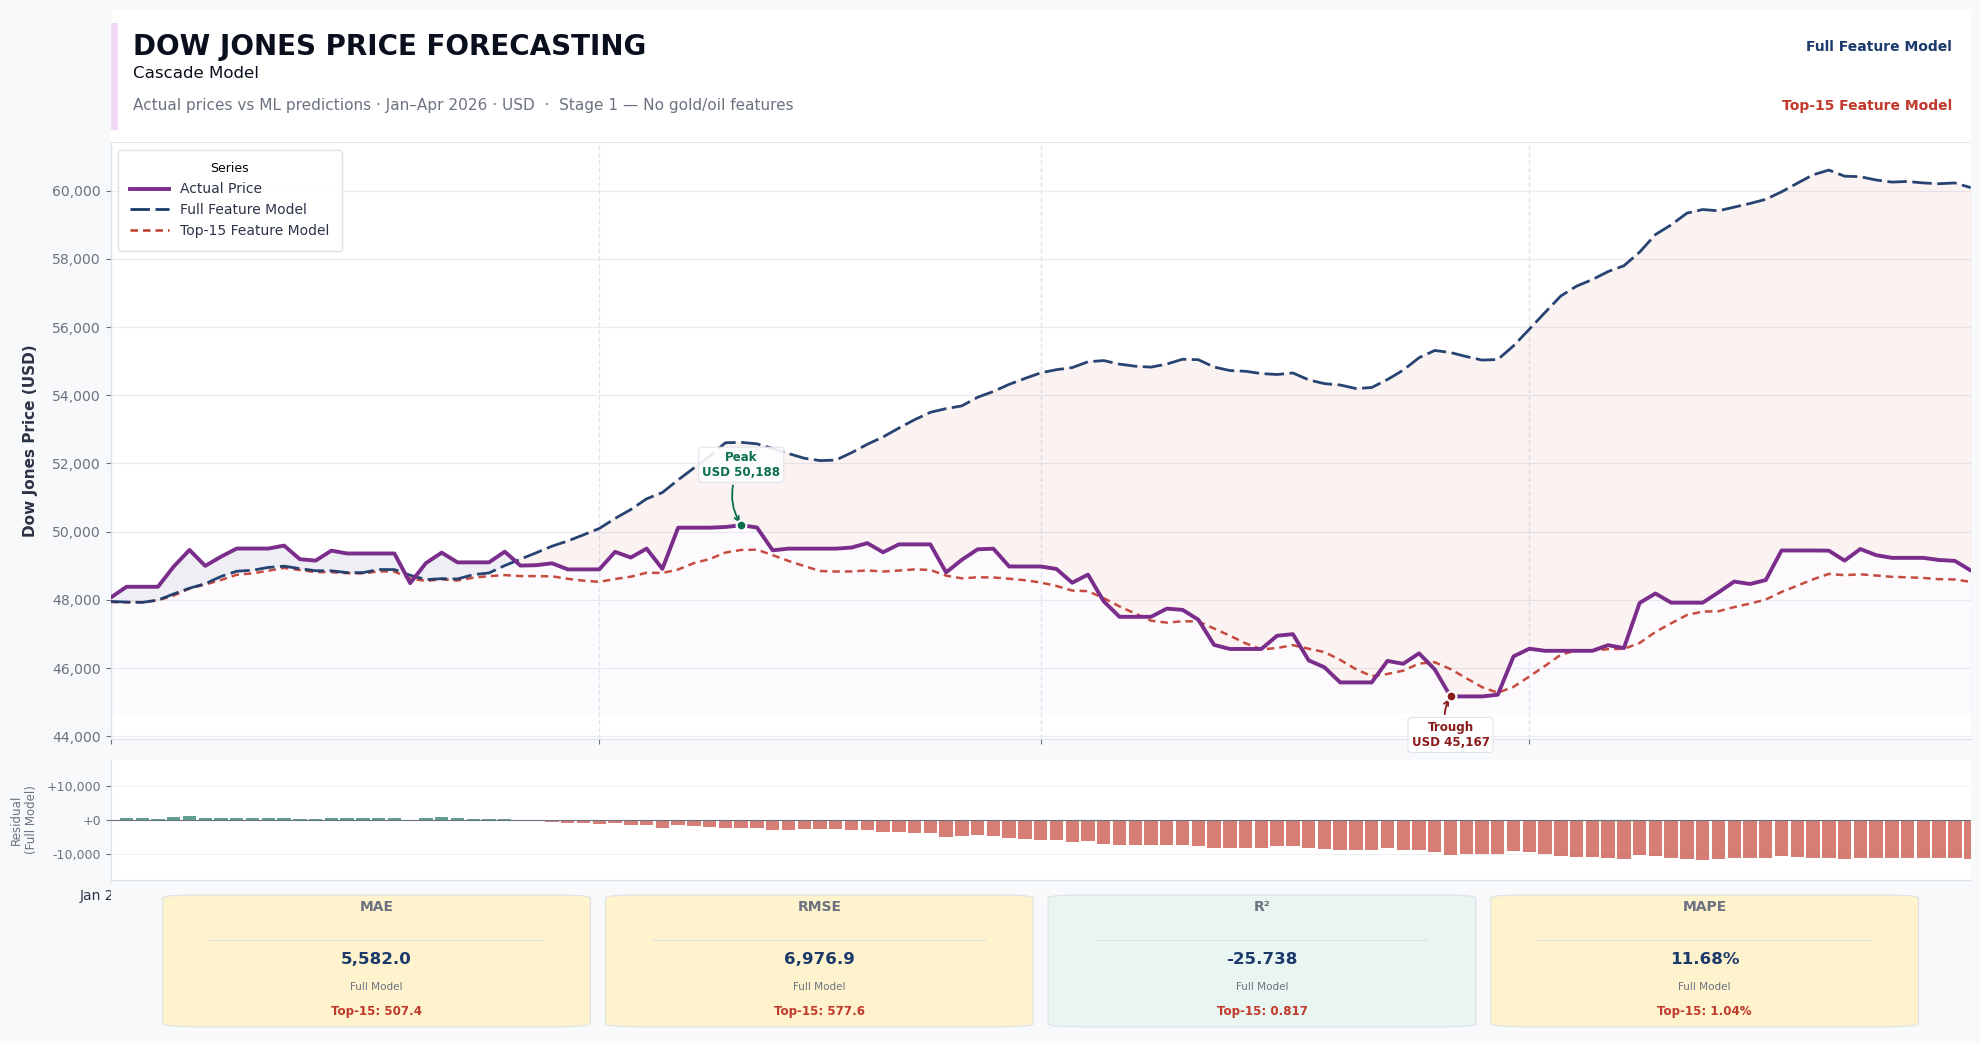

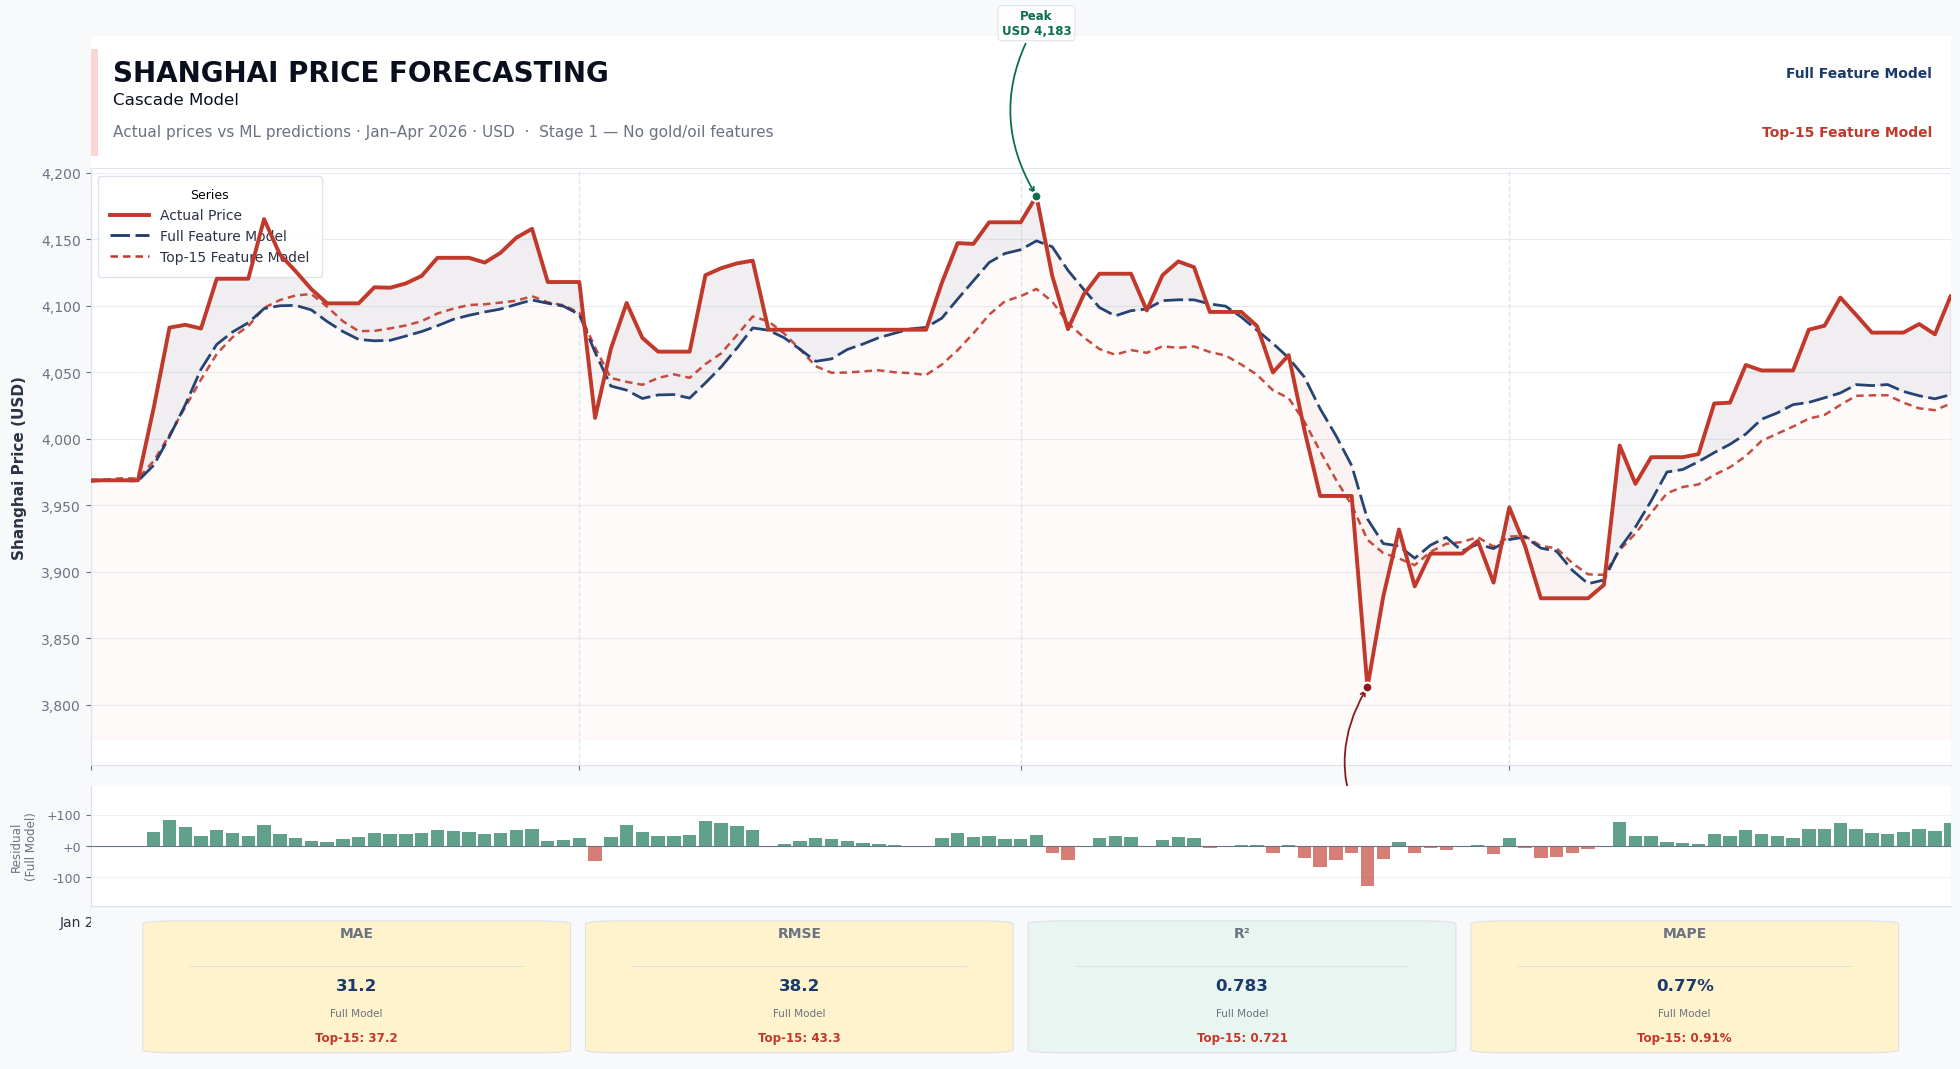

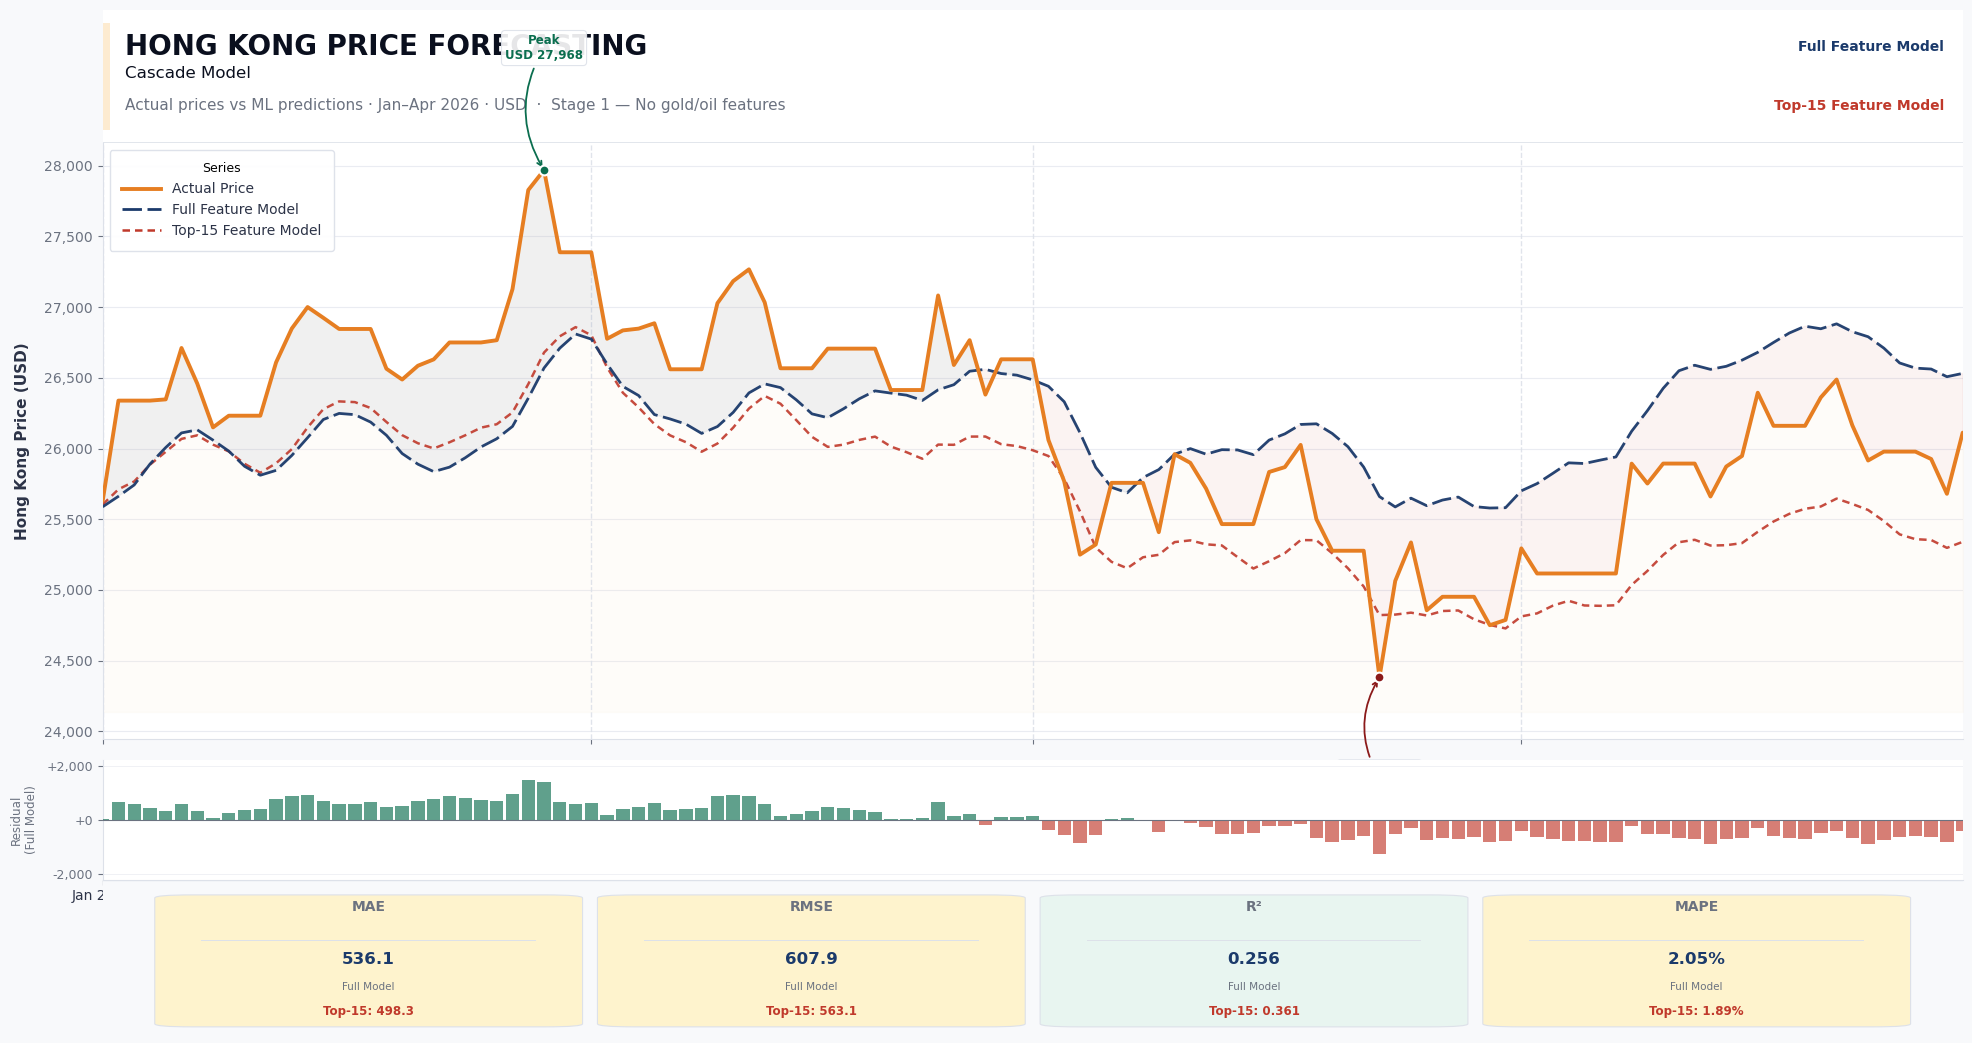

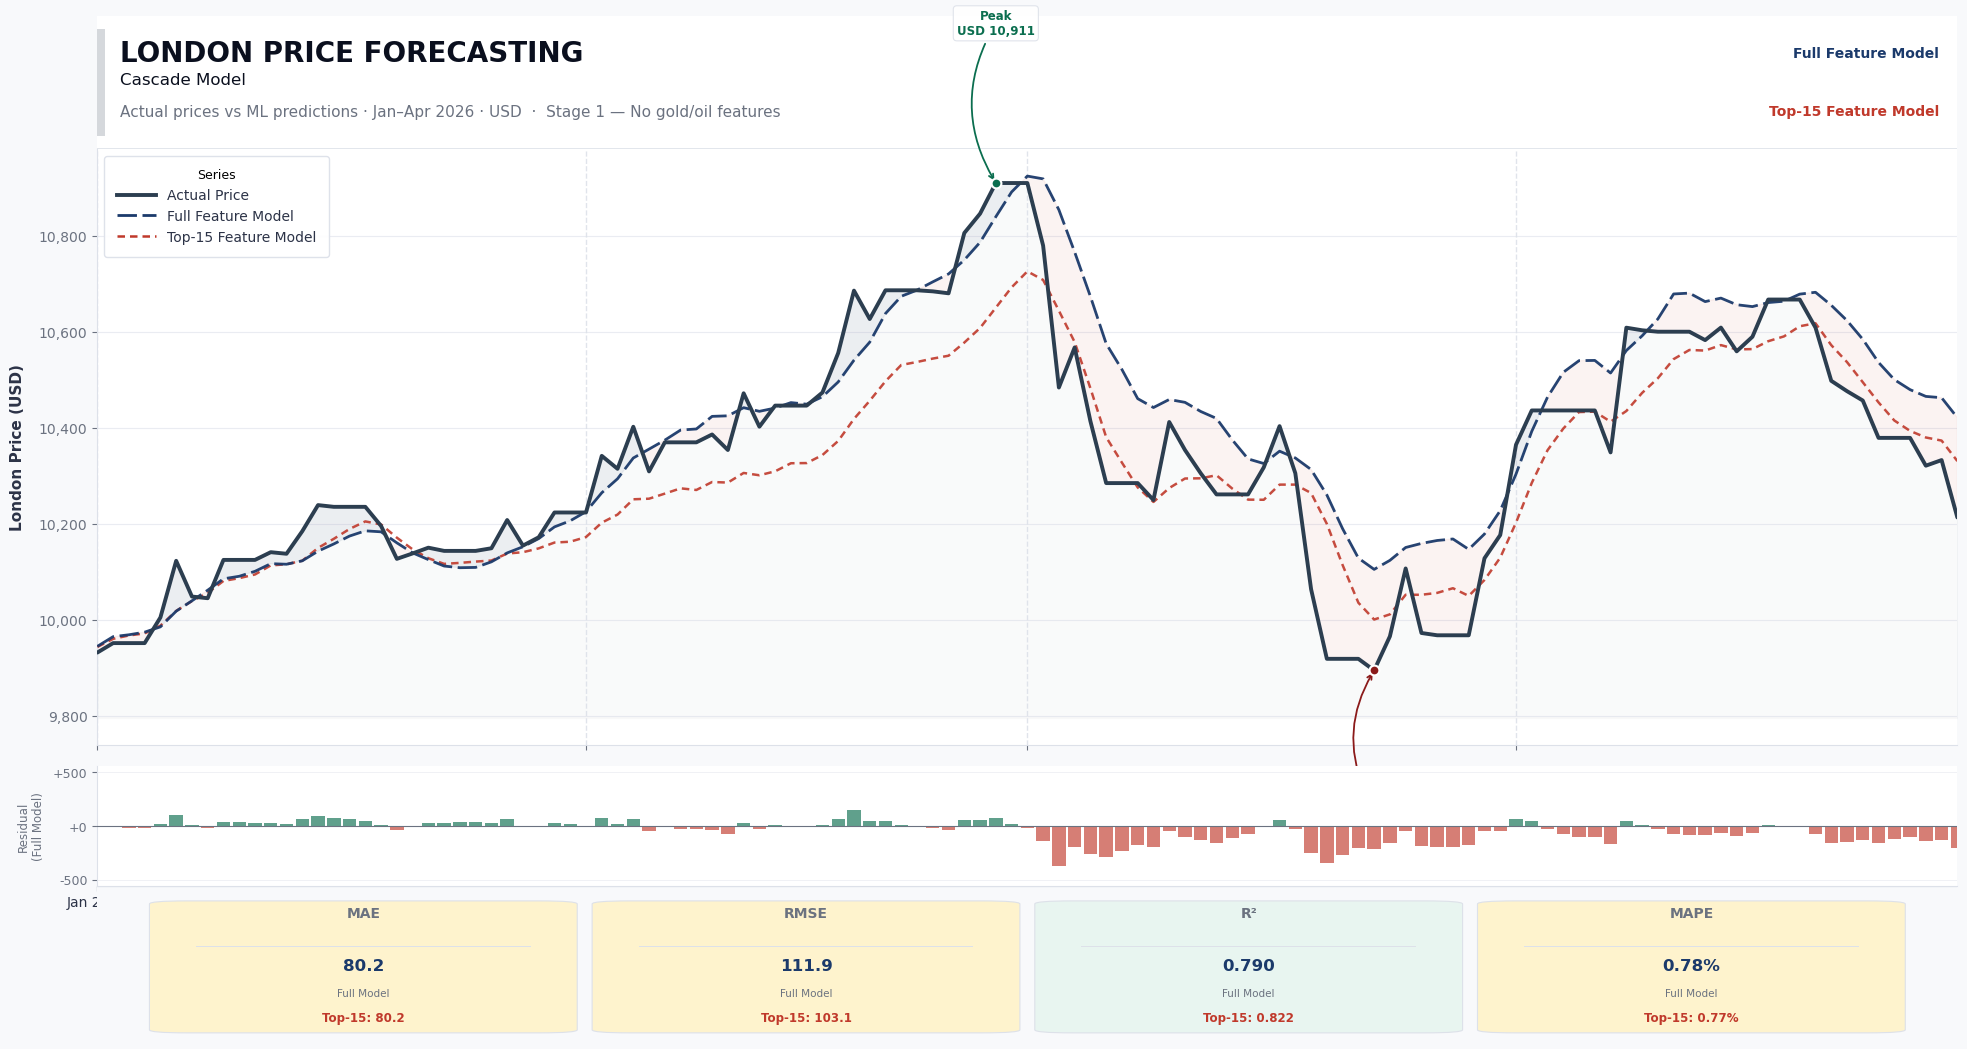

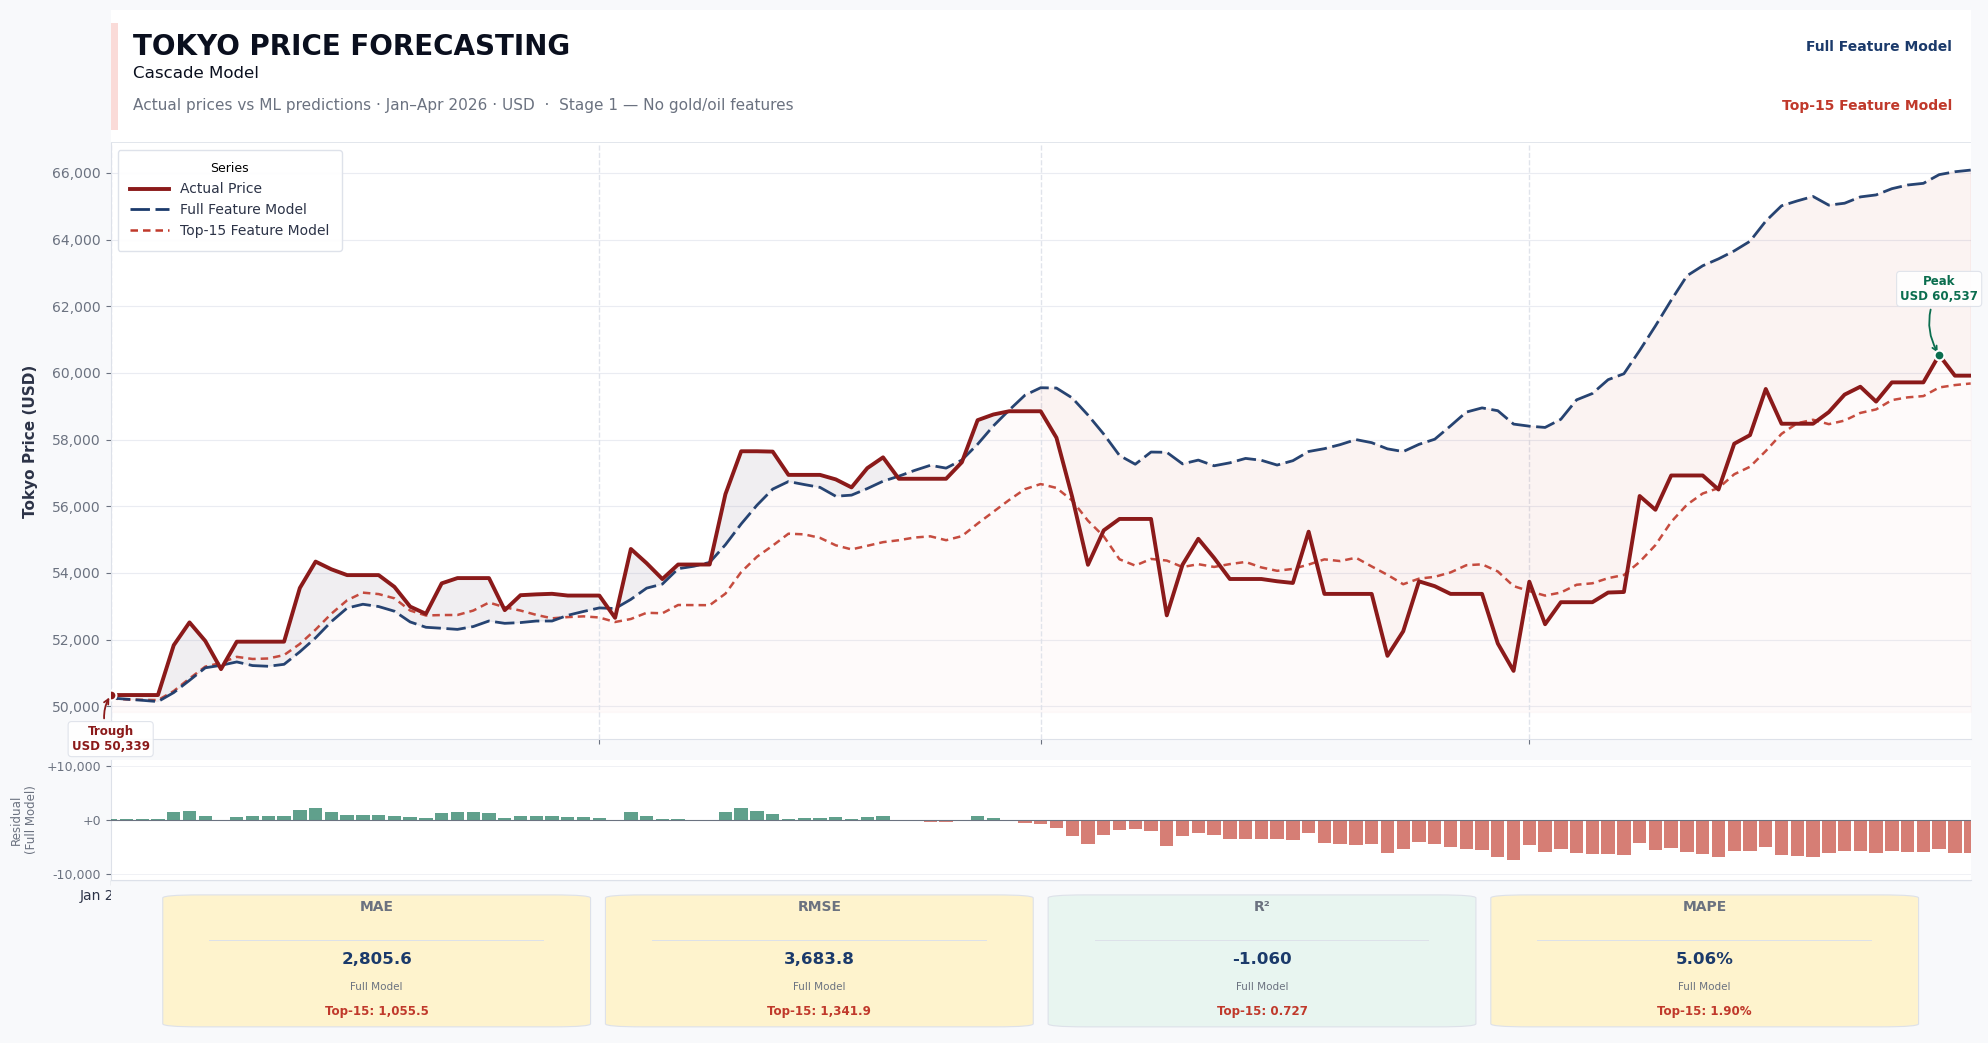

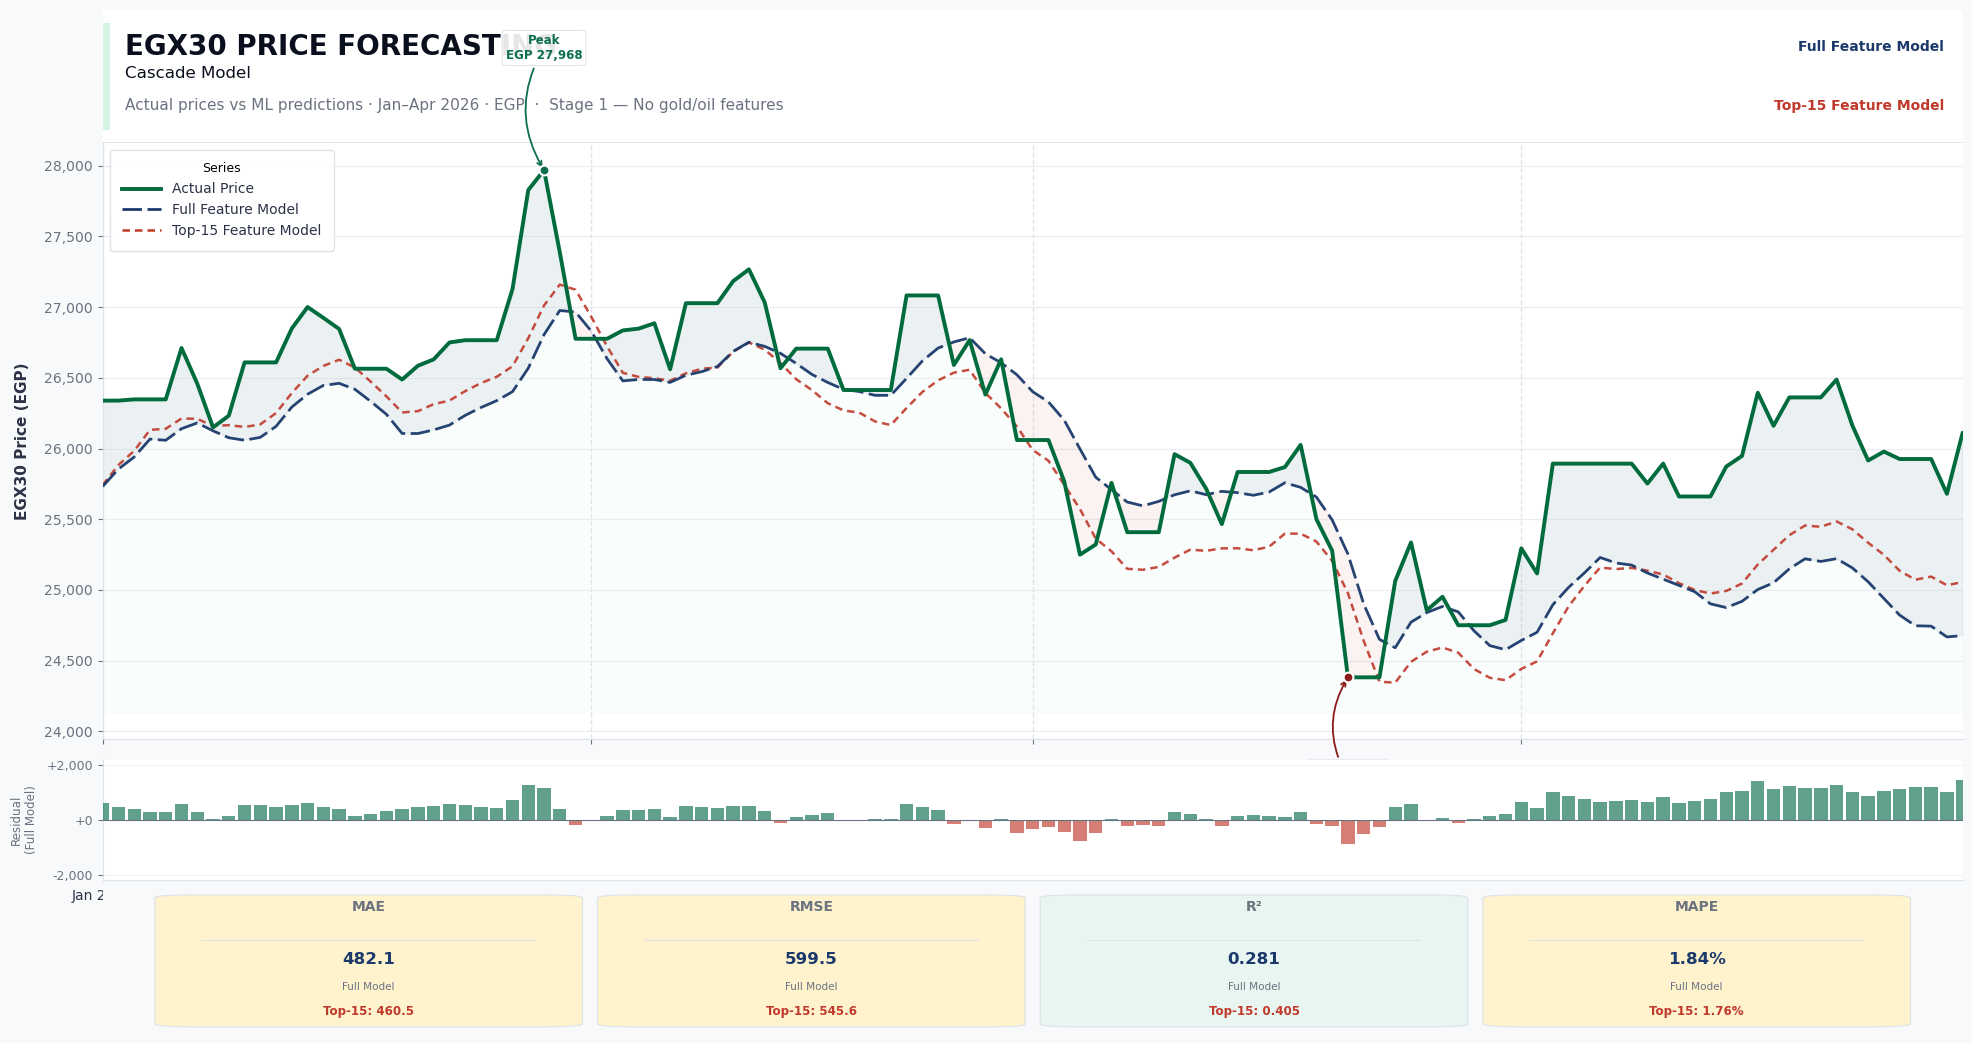

In [6]:
for (name, target_col, currency, accent, fill) in STOCK_MARKETS:

    safe = name.replace(' ','_').replace('&','and').replace('(','').replace(')','')
    # ── 5.1 Load raw data ────────────────────────────────────────────────────
    df = pd.read_csv(ai_data_dir / 'new_master_table.csv')
    df['date'] = pd.to_datetime(df['date'], dayfirst=False, format='mixed', errors='coerce')
    df = df.sort_values('date')

    # ── 5.2 Remove OHLC / leakage columns ───────────────────────────────────
    leakage_kw = BASE_LEAKAGE_KW[:]
    df = df.drop(columns=[c for c in df.columns if any(k in c for k in leakage_kw)], errors='ignore')

    # ── 5.3 Remove GOLD and OIL columns entirely (no leakage from Stage 2/3) ─
    gold_oil_kw = ['gold_price_usd','gold_price','brent_oil_price','oil_price']
    df = df.drop(columns=[c for c in df.columns
                           if any(k in c for k in gold_oil_kw)], errors='ignore')

    # ── 5.4 Remove all OTHER stock market columns ────────────────────────────
    other_stock = [c for c in ALL_STOCK_COLS if c != target_col and c in df.columns]
    df = df.drop(columns=other_stock, errors='ignore')

    # ── 5.5 Macro FE (oil/gold-free) ────────────────────────────────────────
    df['real_rate_us']      = df['usd_fedfunds_value'] - df['cpi_value']
    df['real_rate_eu']      = df['euro_interest_value'] - df['euro_inflation_value']
    df['yield_spread_10_2'] = (df['10y_treasury_historical_data_monthly_value'] -
                               df['2y_treasury_historical_data_monthly_value'])
    df['yield_spread_10_1'] = (df['10y_treasury_historical_data_monthly_value'] -
                               df['1y_treasury_historical_data_monthly_value'])
    df['vix_x_dxy']  = df['vix_price_usd'] * df['dollarindex_value']
    df['vix_mom']    = df['vix_price_usd'].pct_change()

    # ── 5.6 Price FE ────────────────────────────────────────────────────────
    df['log_price'] = np.log(df[target_col])
    df['return']    = df['log_price'].diff()

    for w in [5, 10, 20, 50]:
        df[f'sma_{w}']          = df[target_col].rolling(w).mean().shift(1)
        df[f'price_vs_sma_{w}'] = (df[target_col] / df[f'sma_{w}'] - 1).shift(1)

    _delta = df['return'].clip(lower=0)
    _loss  = (-df['return']).clip(lower=0)
    _avg_g = _delta.rolling(14).mean()
    _avg_l = _loss.rolling(14).mean().replace(0, 1e-9)
    df['rsi_14']   = (100 - 100 / (1 + _avg_g / _avg_l)).shift(1)
    _bb_mid        = df[target_col].rolling(20).mean()
    _bb_std        = df[target_col].rolling(20).std()
    df['bb_width'] = (4 * _bb_std / _bb_mid).shift(1)
    df['day_of_week']    = df['date'].dt.dayofweek
    df['month']          = df['date'].dt.month
    df['quarter']        = df['date'].dt.quarter
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
    df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)
    df['target'] = df['return'].rolling(5).mean().shift(-1).clip(-0.03, 0.03)

    # ── 5.7 Lag FE ──────────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5, 10, 20]:
        df[f'return_lag_{lag}'] = df['return'].shift(lag)
    df['log_price_lag1'] = df['log_price'].shift(1)
    df['vix_lag1']       = df['vix_price_usd'].shift(1)
    df['dxy_lag1']       = df['dollarindex_value'].shift(1)

    # ── 5.8 Vol / Momentum ──────────────────────────────────────────────────
    df['vol_7']          = df['return'].rolling(7).std().shift(1)
    df['vol_20']         = df['return'].rolling(20).std().shift(1)
    df['vol_ratio']      = df['vol_7'] / (df['vol_20'] + 1e-9)
    df['mom_7']          = df['return'].rolling(7).mean().shift(1)
    df['mom_20']         = df['return'].rolling(20).mean().shift(1)
    df['mom_crossover']  = df['mom_7'] - df['mom_20']
    df['price_trend_7']  = df[target_col].rolling(7).mean().shift(1)
    df['price_trend_20'] = df[target_col].rolling(20).mean().shift(1)

    df = df.dropna()

    # ── 5.9 Train / Test split ───────────────────────────────────────────────
    features = [c for c in df.columns if c not in ['date', target_col, 'target']]
    train = df[df['date'] <= TEST_START]
    test  = df[(df['date'] > TEST_START) & (df['date'] <= TEST_END)]
    X_train, y_train = train[features], train['target']
    X_test,  y_test  = test[features],  test['target']

    # ── 5.10 Time-series CV ──────────────────────────────────────────────────
    tscv = TimeSeriesSplit(n_splits=5)
    for i, (tr, val) in enumerate(tscv.split(X_train)):
        m_cv = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.01,
                                  num_leaves=64, max_depth=6, verbose=-1)
        m_cv.fit(X_train.iloc[tr], y_train.iloc[tr])
        pv = m_cv.predict(X_train.iloc[val])

    # ── 5.11 Full model ──────────────────────────────────────────────────────
    model = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01,
                               num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                               random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    selector     = SelectFromModel(model, threshold='median', prefit=True)
    X_train_sel  = selector.transform(X_train)
    X_test_sel   = selector.transform(X_test)
    model.fit(X_train_sel, y_train)
    pred_returns = model.predict(X_test_sel)
    start_price  = train[target_col].iloc[-1]
    prices       = [start_price]
    for r in pred_returns: prices.append(prices[-1] * np.exp(r))
    test = test.copy(); test['pred_price'] = prices[1:]
    mae_f = mean_absolute_error(test[target_col], test['pred_price'])
    dir_f = np.mean(np.sign(test['target']) == np.sign(pred_returns))

    # ── 5.12 Top-15 model ────────────────────────────────────────────────────
    imp_model = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01,
                                   num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                                   random_state=42, verbose=-1)
    imp_model.fit(X_train, y_train)
    top_k       = 15
    importance  = pd.Series(imp_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    top_features = importance.head(top_k).index.tolist()
    X_train_top, X_test_top = X_train[top_features], X_test[top_features]

    top_model = lgb.LGBMRegressor(objective='regression', boosting_type='gbdt',
                                   n_estimators=3000, learning_rate=0.02,
                                   num_leaves=128, max_depth=10, min_child_samples=10,
                                   min_child_weight=1e-3, subsample=0.9, subsample_freq=1,
                                   colsample_bytree=0.9, reg_alpha=0.1, reg_lambda=0.3,
                                   random_state=42, verbose=-1)
    top_model.fit(X_train_top, y_train)
    pred_top    = top_model.predict(X_test_top)
    prices_top  = [start_price]
    for r in pred_top: prices_top.append(prices_top[-1] * np.exp(r))
    test['pred_price_top'] = prices_top[1:]
    mae_t = mean_absolute_error(test[target_col], test['pred_price_top'])
    dir_t = np.mean(np.sign(test['target']) == np.sign(pred_top))

    # ── 5.13 Save top model ───────────────────────────────────────────────────
    with open(ai_data_dir /'models'/ f'cascade_{safe}_top_model.pkl','wb') as f:
        pickle.dump(top_model, f)
    with open(ai_data_dir /'models'/ f'cascade_{safe}_full_model.pkl','wb') as f:
        pickle.dump(model, f)
    # ── 5.14 Store predicted price series (test window only) ─────────────────
    pred_series = pd.Series(test['pred_price_top'].values,
                            index=test['date'].values,
                            name=f'pred_{target_col}')
    stock_pred_series[name] = pred_series

    # ── 5.15 Visualization ───────────────────────────────────────────────────
    save_path = ai_data_dir / 'visualizations'/f'independent_{safe}_stage1_price_prediction.png'
    mae_f2,rmse_f2,r2_f2,mape_f2,mae_t2,rmse_t2,r2_t2,mape_t2 = plot_prediction(
        name, target_col, currency, accent, fill, test,
        save_path=save_path, top_k=top_k,
        subtitle_extra='Stage 1 — No gold/oil features')

    # ── 5.16 Store results ───────────────────────────────────────────────────
    stock_results[name] = {
        'target_col': target_col, 'currency': currency,
        'mae_full': mae_f, 'mae_top': mae_t,
        'direction_full': dir_f, 'direction_top': dir_t,
        'r2_full': r2_f2, 'r2_top': r2_t2,
        'mape_full': mape_f2, 'mape_top': mape_t2,
    }

<h4 style="color: #CEDDF4;">6. Stage 1 — Summary Table</h4>

In [7]:
rows = []
for mkt, r in stock_results.items():
    rows.append({'Market': mkt, 'Currency': r['currency'],
                 'MAE (Top)': round(r['mae_top'],2), 'MAPE (Top) %': round(r['mape_top'],2),
                 'R² (Top)': round(r['r2_top'],4),   'Dir (Top)': round(r['direction_top'],3),
                 'MAE (Full)': round(r['mae_full'],2),'Dir (Full)': round(r['direction_full'],3)})
summary_df = pd.DataFrame(rows).set_index('Market')
summary_df.to_csv(ai_data_dir / 'independent_model_stock_predictions_summary.csv')

<h4 style="color: #CEDDF4;">7. STAGE 2 — Oil Price Prediction</h4>
<p style="color:#AABBCC;">Gold columns are <b>completely removed</b>. Stock market columns in the <b>test window</b> are replaced with Stage-1 predicted prices. Model is trained on data ≤ 2025-12-31 and predicts 2026-01-01 to 2026-04-30.</p>

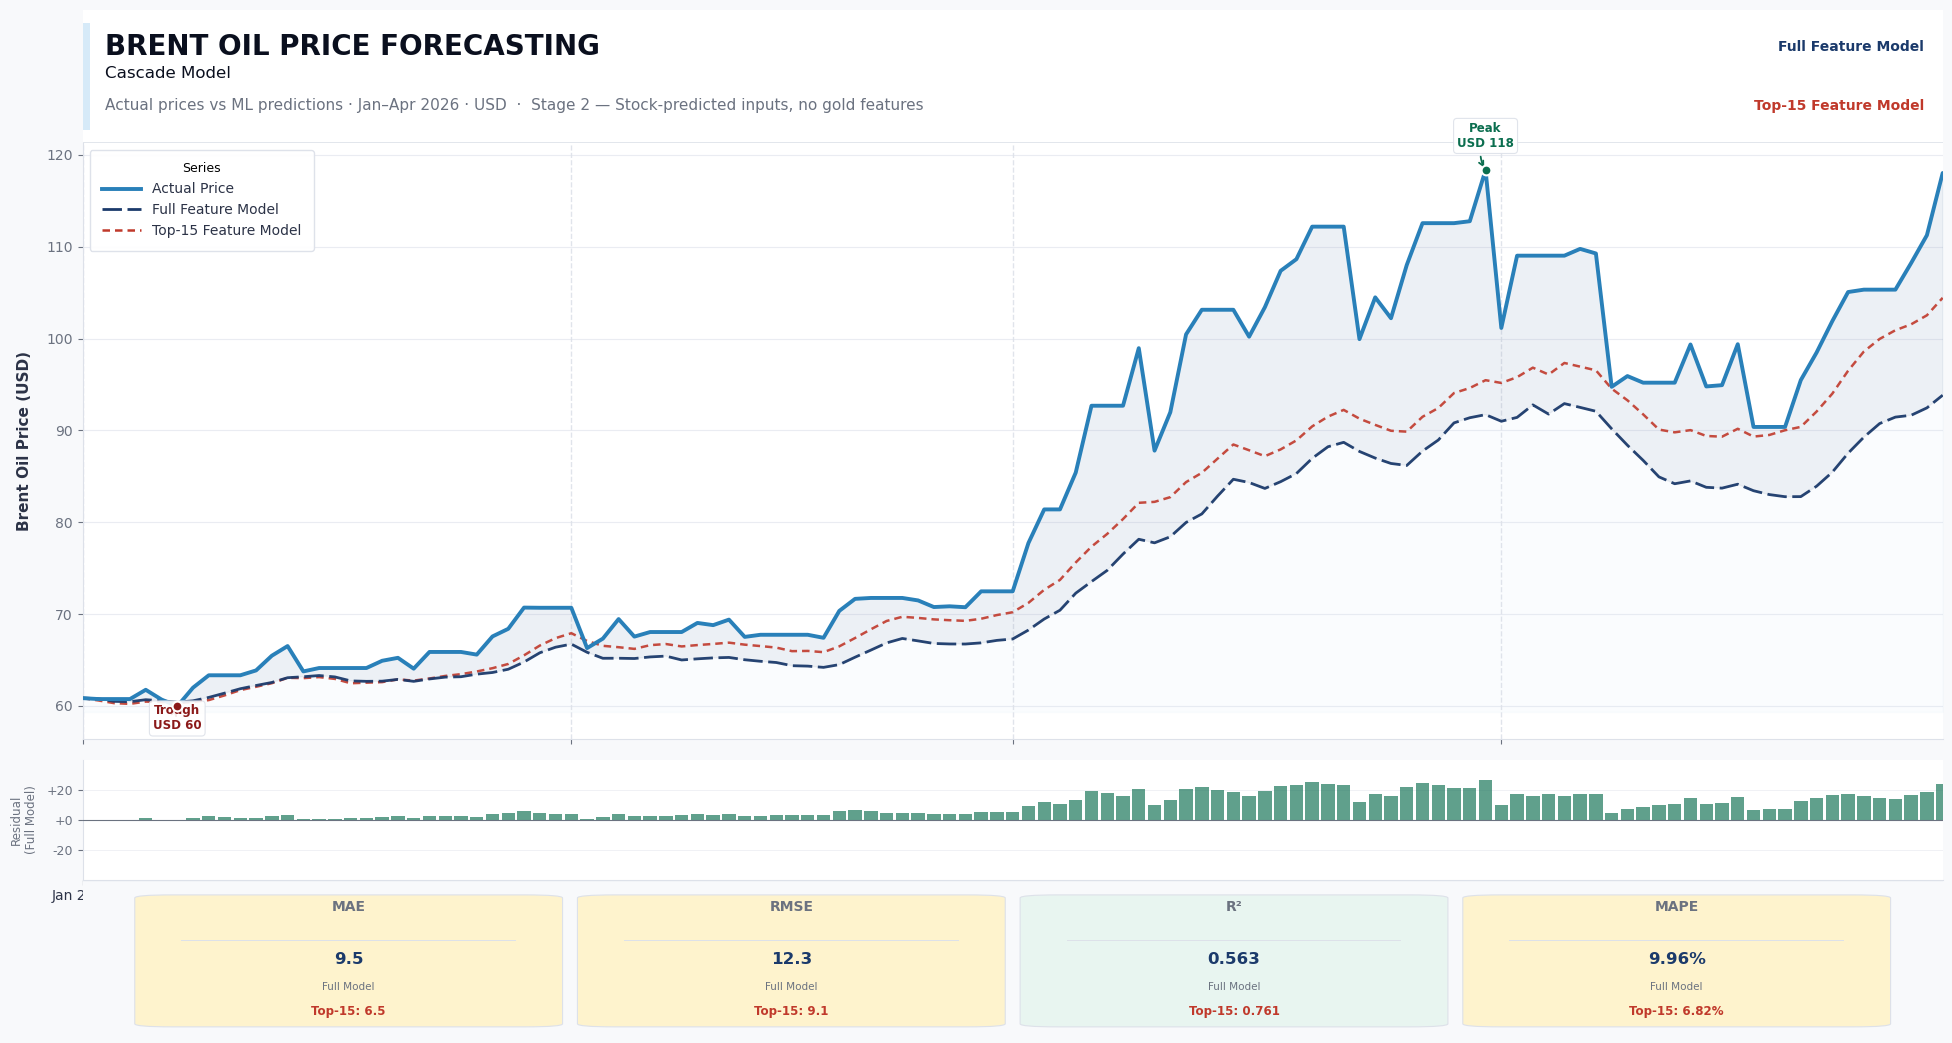

(np.float64(9.512317057516796),
 np.float64(12.261979130338647),
 np.float64(0.5626523281182851),
 np.float64(9.958133908061543),
 np.float64(6.539425179336838),
 np.float64(9.072758859923256),
 np.float64(0.7605667778558677),
 np.float64(6.820082329869262))

In [8]:
OIL_TARGET = 'brent_oil_price_usd'

# ── 7.1 Load raw data ────────────────────────────────────────────────────────
df_oil = pd.read_csv(ai_data_dir / 'new_master_table.csv')
df_oil['date'] = pd.to_datetime(df_oil['date'], dayfirst=False, format='mixed', errors='coerce')
df_oil = df_oil.sort_values('date')

# ── 7.2 Remove OHLC / leakage columns ───────────────────────────────────────
df_oil = df_oil.drop(columns=[c for c in df_oil.columns
    if any(k in c for k in BASE_LEAKAGE_KW)], errors='ignore')

# ── 7.3 Remove ALL gold/silver columns (no proxy leakage) ────────────────────
gold_silver_kw = ['gold_price', 'gold_vi', 'silver_price']
df_oil = df_oil.drop(columns=[c for c in df_oil.columns
    if any(k in c for k in gold_silver_kw)], errors='ignore')

# ── 7.4 Remove all stock columns (will inject predictions for test window) ───
df_oil = df_oil.drop(columns=[c for c in ALL_STOCK_COLS if c in df_oil.columns], errors='ignore')

# ── 7.5 Macro FE ────────────────────────────────────────────────────────────
df_oil['real_rate_us'] = df_oil['usd_fedfunds_value'] - df_oil['cpi_value']
df_oil['real_rate_eu'] = df_oil['euro_interest_value'] - df_oil['euro_inflation_value']
df_oil['oil_x_dxy']   = df_oil['brent_oil_price_usd'] * df_oil['dollarindex_value']
df_oil['vix_x_dxy']   = df_oil['vix_price_usd'] * df_oil['dollarindex_value']
df_oil['vix_mom']     = df_oil['vix_price_usd'].pct_change()
df_oil['oil_mom']     = df_oil['brent_oil_price_usd'].pct_change()

# ── 7.6 Price FE ────────────────────────────────────────────────────────────
df_oil['log_price'] = np.log(df_oil[OIL_TARGET])
df_oil['return']    = df_oil['log_price'].diff()
df_oil['target']    = df_oil['return'].rolling(5).mean().shift(-1).clip(-0.03, 0.03)
for lag in [1, 2, 3, 5, 10, 20]:
    df_oil[f'return_lag_{lag}'] = df_oil['return'].shift(lag)
df_oil['log_price_lag1']  = df_oil['log_price'].shift(1)
df_oil['vix_lag1']        = df_oil['vix_price_usd'].shift(1)
df_oil['oil_lag1']        = df_oil[OIL_TARGET].shift(1)
df_oil['dxy_lag1']        = df_oil['dollarindex_value'].shift(1)
df_oil['vol_7']           = df_oil['return'].rolling(7).std().shift(1)
df_oil['vol_20']          = df_oil['return'].rolling(20).std().shift(1)
df_oil['vol_ratio']       = df_oil['vol_7'] / (df_oil['vol_20'] + 1e-9)
df_oil['mom_7']           = df_oil['return'].rolling(7).mean().shift(1)
df_oil['mom_20']          = df_oil['return'].rolling(20).mean().shift(1)
df_oil['mom_crossover']   = df_oil['mom_7'] - df_oil['mom_20']
df_oil['price_trend_7']   = df_oil[OIL_TARGET].rolling(7).mean().shift(1)
df_oil['price_trend_20']  = df_oil[OIL_TARGET].rolling(20).mean().shift(1)

df_oil = df_oil.dropna()

# ── 7.7 Add stock market prices as features ───────────────────────────────────
# Training rows (≤ 2025-12-31) : use ACTUAL stock prices (no leakage — target is oil)
# Test rows (2026-01-01 to 2026-04-30): replace with Stage-1 PREDICTED prices
# This avoids train/test distribution shift that would occur if training rows were 0.
for mkt_name, mkt_tuple in zip([m[0] for m in USD_STOCK_MARKETS], USD_STOCK_MARKETS):
    _, mkt_col, *_ = mkt_tuple
    raw_df = pd.read_csv(ai_data_dir / 'new_master_table.csv')
    raw_df['date'] = pd.to_datetime(raw_df['date'], dayfirst=False, format='mixed', errors='coerce')
    actual_series = raw_df.set_index('date')[mkt_col]  # actual prices for training
    pred_s        = stock_pred_series[mkt_name]        # predicted prices for test
    col_name      = f'stock_{mkt_col}'
    # map actual prices to all rows, then overwrite test-window rows with predictions
    df_oil[col_name] = df_oil['date'].map(actual_series.to_dict())
    date_to_pred     = dict(zip(pred_s.index, pred_s.values))
    test_mask        = df_oil['date'] > TEST_START
    df_oil.loc[test_mask, col_name] = df_oil.loc[test_mask, 'date'].map(date_to_pred)
    df_oil[col_name] = df_oil[col_name].ffill()  # fill any gaps

# ── 7.8 Train / Test split ───────────────────────────────────────────────────
features_oil = [c for c in df_oil.columns if c not in ['date', OIL_TARGET, 'target']]
train_oil = df_oil[df_oil['date'] <= TEST_START]
test_oil  = df_oil[(df_oil['date'] > TEST_START) & (df_oil['date'] <= TEST_END)]
X_train_oil, y_train_oil = train_oil[features_oil], train_oil['target']
X_test_oil,  y_test_oil  = test_oil[features_oil],  test_oil['target']

# ── 7.9 Time-series CV ───────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr, val) in enumerate(tscv.split(X_train_oil)):
    m_cv = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.01,
                              num_leaves=64, max_depth=6, verbose=-1)
    m_cv.fit(X_train_oil.iloc[tr], y_train_oil.iloc[tr])
    pv = m_cv.predict(X_train_oil.iloc[val])

# ── 7.10 Full model ──────────────────────────────────────────────────────────
oil_model_full = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01,
                                    num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbose=-1)
oil_model_full.fit(X_train_oil, y_train_oil)
selector_oil  = SelectFromModel(oil_model_full, threshold='median', prefit=True)
X_tr_sel      = selector_oil.transform(X_train_oil)
X_te_sel      = selector_oil.transform(X_test_oil)
oil_model_full.fit(X_tr_sel, y_train_oil)
pred_ret_oil  = oil_model_full.predict(X_te_sel)
start_oil     = train_oil[OIL_TARGET].iloc[-1]
prices_oil    = [start_oil]
for r in pred_ret_oil: prices_oil.append(prices_oil[-1] * np.exp(r))
test_oil = test_oil.copy(); test_oil['pred_price'] = prices_oil[1:]
mae_oil_f = mean_absolute_error(test_oil[OIL_TARGET], test_oil['pred_price'])
dir_oil_f = np.mean(np.sign(test_oil['target']) == np.sign(pred_ret_oil))

# ── 7.11 Top-15 model ────────────────────────────────────────────────────────
imp_oil = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01,
                             num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbose=-1)
imp_oil.fit(X_train_oil, y_train_oil)
top_k_oil     = 15
imp_series    = pd.Series(imp_oil.feature_importances_, index=X_train_oil.columns).sort_values(ascending=False)
top_oil_feats = imp_series.head(top_k_oil).index.tolist()
X_tr_top_oil  = X_train_oil[top_oil_feats]
X_te_top_oil  = X_test_oil[top_oil_feats]

oil_top_model = lgb.LGBMRegressor(objective='regression', boosting_type='gbdt',
                                   n_estimators=3000, learning_rate=0.02,
                                   num_leaves=128, max_depth=10, min_child_samples=10,
                                   min_child_weight=1e-3, subsample=0.9, subsample_freq=1,
                                   colsample_bytree=0.9, reg_alpha=0.1, reg_lambda=0.3,
                                   random_state=42, verbose=-1)
oil_top_model.fit(X_tr_top_oil, y_train_oil)
pred_top_oil  = oil_top_model.predict(X_te_top_oil)
prices_top_oil = [start_oil]
for r in pred_top_oil: prices_top_oil.append(prices_top_oil[-1] * np.exp(r))
test_oil['pred_price_top'] = prices_top_oil[1:]
mae_oil_t = mean_absolute_error(test_oil[OIL_TARGET], test_oil['pred_price_top'])
dir_oil_t = np.mean(np.sign(test_oil['target']) == np.sign(pred_top_oil))

# ── 7.12 Save models ─────────────────────────────────────────────────────────
with open(ai_data_dir /'models'/ 'cascade_oil_full_model.pkl', 'wb') as f:
    pickle.dump(oil_model_full, f)
with open(ai_data_dir /'models'/ 'cascade_oil_top_model.pkl', 'wb') as f:
    pickle.dump(oil_top_model, f)

# ── 7.13 Store oil predicted series for Stage 3 ──────────────────────────────
oil_pred_series = pd.Series(test_oil['pred_price_top'].values,
                             index=test_oil['date'].values,
                             name='pred_brent_oil_price_usd')

# ── 7.14 Visualization ───────────────────────────────────────────────────────
save_path_oil = ai_data_dir /'visualizations'/ 'cascade_model_oil_price_prediction.png'
plot_prediction('Brent Oil', OIL_TARGET, 'USD', '#2980B9', '#D6EAF8',
                test_oil, save_path=save_path_oil, top_k=top_k_oil,
                subtitle_extra='Stage 2 — Stock-predicted inputs, no gold features')

<h4 style="color: #CEDDF4;">8. STAGE 3 — Gold Price Prediction</h4>
<p style="color:#AABBCC;">The test window uses <b>Stage-1 stock predictions</b> and <b>Stage-2 oil predictions</b> as inputs. Gold model trained on data ≤ 2025-12-31, predicts 2026-01-01 to 2026-04-30. A CSV (date, predicted_value, actual_value) and a visualization are produced.</p>

  Top Model   →  MAE: 158.95  |  Direction: 0.824


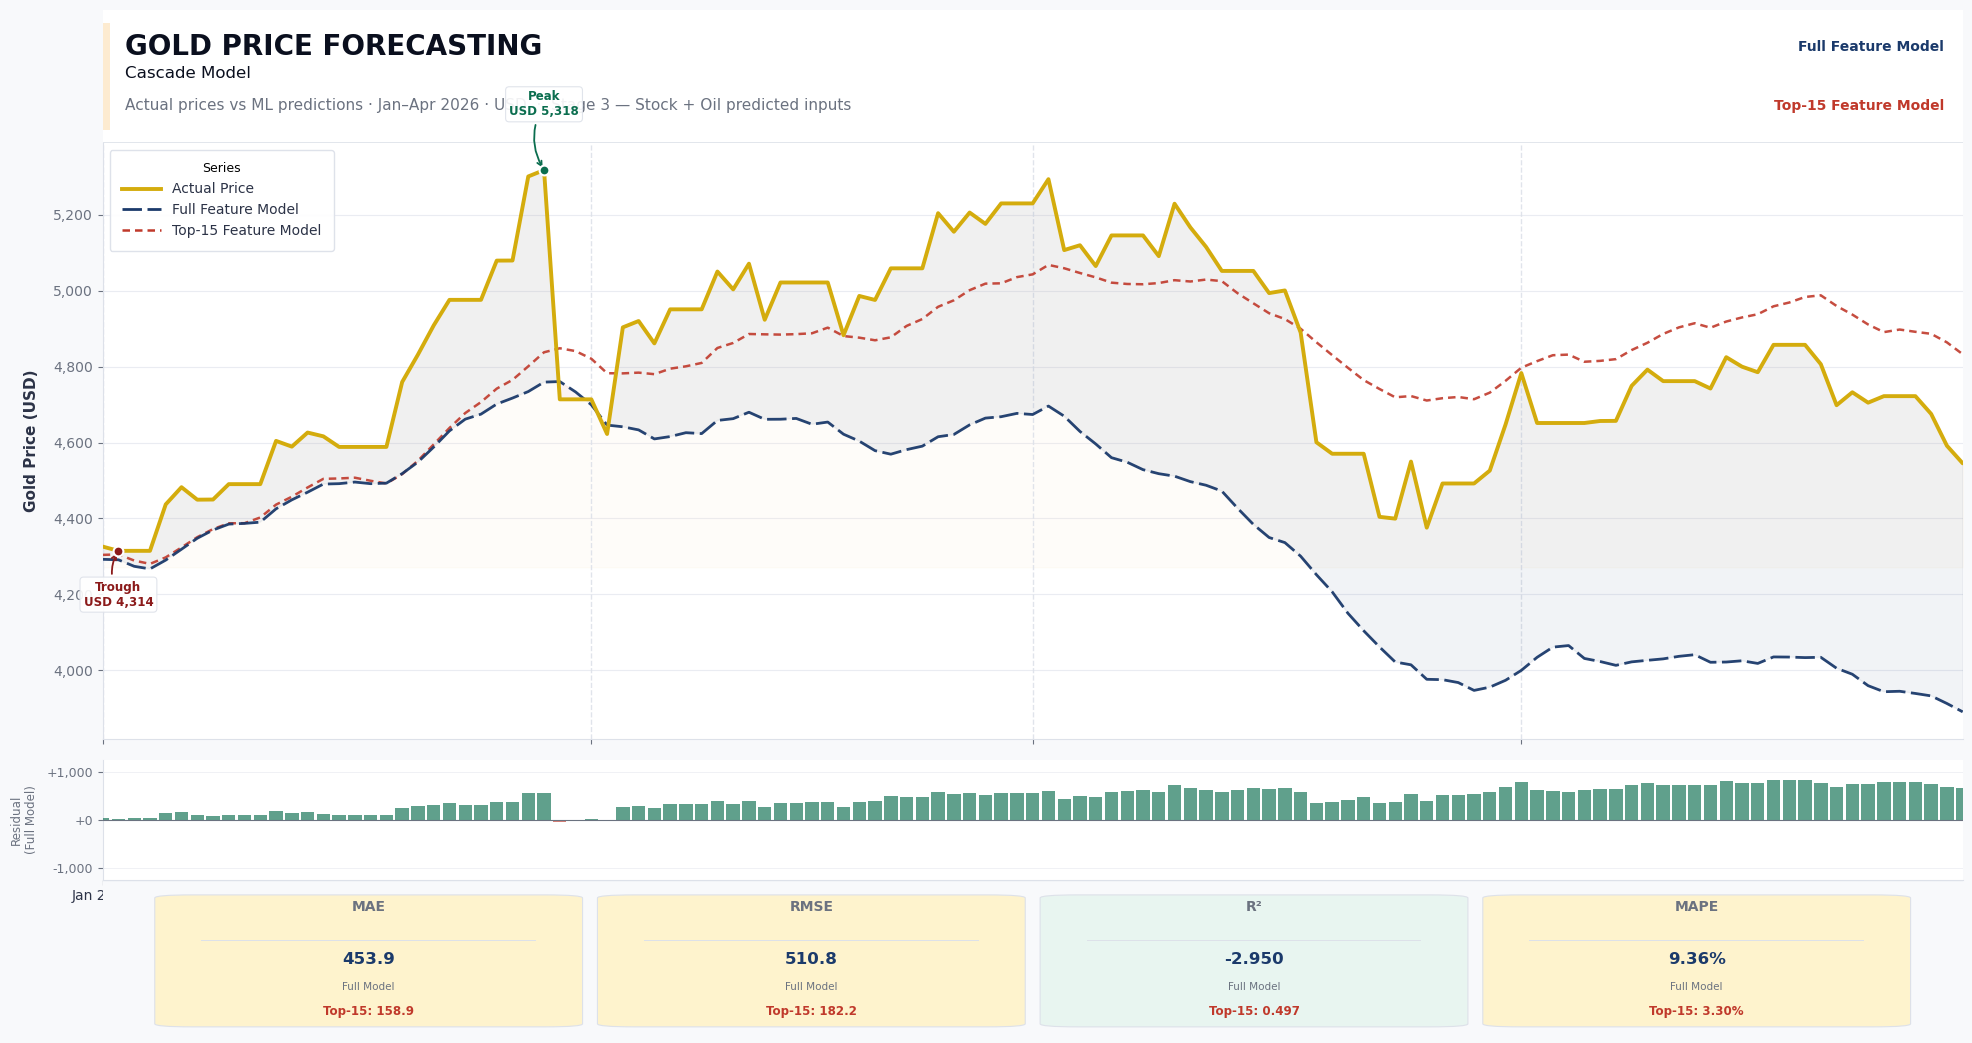

In [9]:
GOLD_TARGET = 'gold_price_usd'

# ── 8.1 Load raw data ────────────────────────────────────────────────────────
df_gold = pd.read_csv(ai_data_dir / 'new_master_table.csv')
df_gold['date'] = pd.to_datetime(df_gold['date'], dayfirst=False, format='mixed', errors='coerce')
df_gold = df_gold.sort_values('date')

# ── 8.2 Remove OHLC / leakage columns ───────────────────────────────────────
df_gold = df_gold.drop(columns=[c for c in df_gold.columns
    if any(k in c for k in BASE_LEAKAGE_KW)], errors='ignore')

# ── 8.3 Remove all raw stock columns (will inject Stage-1 predictions) ───────
df_gold = df_gold.drop(columns=[c for c in ALL_STOCK_COLS if c in df_gold.columns], errors='ignore')

# ── 8.4 Macro FE (oil and stock cols treated as raw features here; ────────────
#         test-window values will be replaced by predictions below)
df_gold['real_rate_us'] = df_gold['usd_fedfunds_value'] - df_gold['cpi_value']
df_gold['real_rate_eu'] = df_gold['euro_interest_value'] - df_gold['euro_inflation_value']
df_gold['oil_x_dxy']   = df_gold['brent_oil_price_usd'] * df_gold['dollarindex_value']
df_gold['vix_x_dxy']   = df_gold['vix_price_usd'] * df_gold['dollarindex_value']
df_gold['gold_x_dxy']  = df_gold['gold_price_usd'] * df_gold['dollarindex_value']
df_gold['vix_mom']     = df_gold['vix_price_usd'].pct_change()
df_gold['oil_mom']     = df_gold['brent_oil_price_usd'].pct_change()
df_gold['gold_mom']    = df_gold['gold_price_usd'].pct_change()

# ── 8.5 Price FE ────────────────────────────────────────────────────────────
df_gold['log_price'] = np.log(df_gold[GOLD_TARGET])
df_gold['return']    = df_gold['log_price'].diff()
df_gold['target']    = df_gold['return'].rolling(5).mean().shift(-1).clip(-0.03, 0.03)
for lag in [1, 2, 3, 5, 10, 20]:
    df_gold[f'return_lag_{lag}'] = df_gold['return'].shift(lag)
df_gold['log_price_lag1']  = df_gold['log_price'].shift(1)
df_gold['vix_lag1']        = df_gold['vix_price_usd'].shift(1)
df_gold['gold_lag1']       = df_gold[GOLD_TARGET].shift(1)
df_gold['oil_lag1']        = df_gold['brent_oil_price_usd'].shift(1)
df_gold['dxy_lag1']        = df_gold['dollarindex_value'].shift(1)
df_gold['vol_7']           = df_gold['return'].rolling(7).std().shift(1)
df_gold['vol_20']          = df_gold['return'].rolling(20).std().shift(1)
df_gold['vol_ratio']       = df_gold['vol_7'] / (df_gold['vol_20'] + 1e-9)
df_gold['mom_7']           = df_gold['return'].rolling(7).mean().shift(1)
df_gold['mom_20']          = df_gold['return'].rolling(20).mean().shift(1)
df_gold['mom_crossover']   = df_gold['mom_7'] - df_gold['mom_20']
df_gold['price_trend_7']   = df_gold[GOLD_TARGET].rolling(7).mean().shift(1)
df_gold['price_trend_20']  = df_gold[GOLD_TARGET].rolling(20).mean().shift(1)

df_gold = df_gold.dropna()

# ── 8.6 Add stock market prices as features ───────────────────────────────────
# Training rows: actual stock prices; Test rows: Stage-1 predicted prices
for mkt_name, mkt_tuple in zip([m[0] for m in USD_STOCK_MARKETS], USD_STOCK_MARKETS):
    _, mkt_col, *_ = mkt_tuple
    raw_df = pd.read_csv(ai_data_dir / 'new_master_table.csv')
    raw_df['date'] = pd.to_datetime(raw_df['date'], dayfirst=False, format='mixed', errors='coerce')
    actual_series = raw_df.set_index('date')[mkt_col]
    pred_s        = stock_pred_series[mkt_name]
    col_name      = f'stock_{mkt_col}'
    df_gold[col_name] = df_gold['date'].map(actual_series.to_dict())
    date_to_pred      = dict(zip(pred_s.index, pred_s.values))
    test_mask         = df_gold['date'] > TEST_START
    df_gold.loc[test_mask, col_name] = df_gold.loc[test_mask, 'date'].map(date_to_pred)
    df_gold[col_name] = df_gold[col_name].ffill()

# ── 8.7 Train / Test split ───────────────────────────────────────────────────
# Drop features derived directly from gold_price_usd (the target) to prevent
# look-ahead leakage in the test window — the model cannot know actual gold prices.
gold_derived = ['gold_x_dxy', 'gold_lag1', 'gold_mom']
df_gold = df_gold.drop(columns=gold_derived, errors='ignore')
features_gold = [c for c in df_gold.columns if c not in ['date', GOLD_TARGET, 'target']]
train_gold = df_gold[df_gold['date'] <= TEST_START]
test_gold  = df_gold[(df_gold['date'] > TEST_START) & (df_gold['date'] <= TEST_END)]
X_train_gold, y_train_gold = train_gold[features_gold], train_gold['target']
X_test_gold,  y_test_gold  = test_gold[features_gold],  test_gold['target']

# ── 8.8 Inject Stage-2 oil predictions into TEST features ────────────────────
X_test_gold = X_test_gold.copy()
oil_date_map = dict(zip(oil_pred_series.index, oil_pred_series.values))
test_dates   = test_gold['date'].values

# inject same-day predicted oil into brent_oil_price_usd
if 'brent_oil_price_usd' in X_test_gold.columns:
    X_test_gold['brent_oil_price_usd'] = pd.Series(test_dates).map(oil_date_map).values
# inject correctly lagged predicted oil into oil_lag1 (previous day's predicted price)
if 'oil_lag1' in X_test_gold.columns:
    oil_pred_shifted = dict(zip(
        oil_pred_series.index[1:],      # dates shifted forward by 1
        oil_pred_series.values[:-1]     # previous day's predicted value
    ))
    X_test_gold['oil_lag1'] = pd.Series(test_dates).map(oil_pred_shifted).bfill().values

# Rebuild oil-derived features for test rows
if 'dollarindex_value' in X_test_gold.columns:
    X_test_gold['oil_x_dxy'] = X_test_gold['brent_oil_price_usd'] * X_test_gold['dollarindex_value']
X_test_gold['oil_mom'] = X_test_gold['brent_oil_price_usd'].pct_change().fillna(0)

# ── 8.9 Time-series CV ───────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr, val) in enumerate(tscv.split(X_train_gold)):
    m_cv = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.01,
                              num_leaves=64, max_depth=6, verbose=-1)
    m_cv.fit(X_train_gold.iloc[tr], y_train_gold.iloc[tr])
    pv = m_cv.predict(X_train_gold.iloc[val])

# ── 8.10 Full model ──────────────────────────────────────────────────────────
gold_model_full = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01,
                                     num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                                     random_state=42, verbose=-1)
gold_model_full.fit(X_train_gold, y_train_gold)
selector_gold   = SelectFromModel(gold_model_full, threshold='median', prefit=True)
X_tr_sel_g      = selector_gold.transform(X_train_gold)
X_te_sel_g      = selector_gold.transform(X_test_gold)
gold_model_full.fit(X_tr_sel_g, y_train_gold)
pred_ret_gold   = gold_model_full.predict(X_te_sel_g)
start_gold      = train_gold[GOLD_TARGET].iloc[-1]
prices_gold     = [start_gold]
for r in pred_ret_gold: prices_gold.append(prices_gold[-1] * np.exp(r))
test_gold = test_gold.copy(); test_gold['pred_price'] = prices_gold[1:]
mae_gold_f = mean_absolute_error(test_gold[GOLD_TARGET], test_gold['pred_price'])
dir_gold_f = np.mean(np.sign(test_gold['target']) == np.sign(pred_ret_gold))

# ── 8.11 Top-15 model ────────────────────────────────────────────────────────
imp_gold = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01,
                              num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbose=-1)
imp_gold.fit(X_train_gold, y_train_gold)
top_k_gold     = 15
imp_s_gold     = pd.Series(imp_gold.feature_importances_, index=X_train_gold.columns).sort_values(ascending=False)
top_gold_feats = imp_s_gold.head(top_k_gold).index.tolist()
X_tr_top_gold  = X_train_gold[top_gold_feats]
X_te_top_gold  = X_test_gold[top_gold_feats]

gold_top_model = lgb.LGBMRegressor(objective='regression', boosting_type='gbdt',
                                    n_estimators=3000, learning_rate=0.02,
                                    num_leaves=128, max_depth=10, min_child_samples=10,
                                    min_child_weight=1e-3, subsample=0.9, subsample_freq=1,
                                    colsample_bytree=0.9, reg_alpha=0.1, reg_lambda=0.3,
                                    random_state=42, verbose=-1)
gold_top_model.fit(X_tr_top_gold, y_train_gold)
pred_top_gold  = gold_top_model.predict(X_te_top_gold)
prices_top_gold = [start_gold]
for r in pred_top_gold: prices_top_gold.append(prices_top_gold[-1] * np.exp(r))
test_gold['pred_price_top'] = prices_top_gold[1:]
mae_gold_t = mean_absolute_error(test_gold[GOLD_TARGET], test_gold['pred_price_top'])
dir_gold_t = np.mean(np.sign(test_gold['target']) == np.sign(pred_top_gold))
print(f"  Top Model   →  MAE: {mae_gold_t:.2f}  |  Direction: {dir_gold_t:.3f}")

# ── 8.12 Save models ─────────────────────────────────────────────────────────
with open(ai_data_dir /'models' /'cascade_gold_full_model.pkl', 'wb') as f:
    pickle.dump(gold_model_full, f)
with open(ai_data_dir /'models' / 'cascade_gold__top_model.pkl', 'wb') as f:
    pickle.dump(gold_top_model, f)

# ── 8.13 Visualization ───────────────────────────────────────────────────────
save_path_gold = ai_data_dir / 'visualizations'/ 'gold_stage3_price_prediction.png'
plot_prediction('Gold', GOLD_TARGET, 'USD', '#D4AC0D', '#FDEBD0',
                test_gold, save_path=save_path_gold, top_k=top_k_gold,
                subtitle_extra='Stage 3 — Stock + Oil predicted inputs')

# ── 8.14 CSV export: date / predicted_value / actual_value ───────────────────
gold_csv = test_gold[['date', 'pred_price_top', GOLD_TARGET]].copy()
gold_csv.columns = ['date', 'predicted_value', 'actual_value']
gold_csv['date'] = pd.to_datetime(gold_csv['date']).dt.strftime('%Y-%m-%d')
csv_path = ai_data_dir / 'cascade_model_gold_predicted_vs_actual.csv'
gold_csv.to_csv(csv_path, index=False)

<h4 style="color: #CEDDF4;">9. Final Pipeline Summary</h4>

In [10]:
print("="*65)
print("  3-STAGE CAUSAL CASCADE — COMPLETE")
print("="*65)
print()
print("STAGE 1 — Stock Markets (no gold/oil features)")
print("-"*55)
for mkt, r in stock_results.items():
    print(f"  {mkt:<14} MAE={r['mae_top']:>8.2f}  "
          f"R²={r['r2_top']:>6.3f}  Dir={r['direction_top']:.3f}")
print()
print("STAGE 2 — Oil  (stocks injected; no gold features)")
print(f"  MAE (full)={mae_oil_f:.2f}  MAE (top)={mae_oil_t:.2f}  Dir={dir_oil_t:.3f}")
print()
print("STAGE 3 — Gold  (stocks + oil injected)")
print(f"  MAE (full)={mae_gold_f:.2f}  MAE (top)={mae_gold_t:.2f}  Dir={dir_gold_t:.3f}")
print()
print("Outputs in  ai model/")
print("  stage1_stock_predictions_summary.csv")
print("  <MarketName>_stage1_price_prediction.png  (x7)")
print("  <MarketName>_stage1_top_model.pkl          (x7)")
print("  oil_stage2_price_prediction.png")
print("  oil_stage2_top_model.pkl")
print("  gold_stage3_price_prediction.png")
print("  gold_stage3_top_model.pkl")
print("  gold_predicted_vs_actual.csv")

  3-STAGE CAUSAL CASCADE — COMPLETE

STAGE 1 — Stock Markets (no gold/oil features)
-------------------------------------------------------
  NASDAQ         MAE=  321.45  R²= 0.790  Dir=0.798
  S&P 500        MAE=   63.18  R²= 0.831  Dir=0.798
  Dow Jones      MAE=  507.37  R²= 0.817  Dir=0.807
  Shanghai       MAE=   37.15  R²= 0.721  Dir=0.782
  Hong Kong      MAE=  498.30  R²= 0.361  Dir=0.832
  London         MAE=   80.15  R²= 0.822  Dir=0.874
  Tokyo          MAE= 1055.52  R²= 0.727  Dir=0.807
  EGX30          MAE=  460.47  R²= 0.405  Dir=0.849

STAGE 2 — Oil  (stocks injected; no gold features)
  MAE (full)=9.51  MAE (top)=6.54  Dir=0.773

STAGE 3 — Gold  (stocks + oil injected)
  MAE (full)=453.93  MAE (top)=158.95  Dir=0.824

Outputs in  ai model/
  stage1_stock_predictions_summary.csv
  <MarketName>_stage1_price_prediction.png  (x7)
  <MarketName>_stage1_top_model.pkl          (x7)
  oil_stage2_price_prediction.png
  oil_stage2_top_model.pkl
  gold_stage3_price_prediction.png
